# Phase separation with simple 2D autoencoders and an EGNN

This notebook builds the benchmark in four stages:

1. **Liquid vs FCC:** an easier binary phase-separation baseline.
2. **FCC vs HCP:** a difficult binary comparison that exposes the limitations of local reconstruction with a simple dense autoencoder.
3. **Liquid vs FCC vs HCP:** the same invariant-input experiment with all three classes.
4. **EGNN:** a neighborhood graph encoder with invariant pooling, a dense two-dimensional bottleneck, and target-specific MLP decoders.

Every bottleneck is exactly two-dimensional, so latent plots show the learned coordinates directly—there is no PCA, t-SNE, or UMAP. Each simple-autoencoder comparison uses a visual run plus **30 complete seeded runs** for its robustness distribution.

| comparison | inputs or reconstruction targets | first shell | second shell |
|---|---|---|---|
| liquid vs FCC | center distances, pairwise distances, vectors, $q_l$ | 12 NN | 18 NN |
| FCC vs HCP | center distances, pairwise distances, central triplet angles, $q_l$ | 12 NN | 18 NN |
| all three phases | center distances, pairwise distances, central triplet angles, $q_l$ | 12 NN | 18 NN |
| EGNN, all three phases | graph input; separate MLP decoders for the four invariant targets | 12 NN | 18 NN |

The $q_l$ convention is standard/non-averaged for one shell and Lechner–Dellago averaged for two shells. See the data-integrity warning below: the currently available second-shell NPZs contain 18 geometric neighbors but stored averaged $q_l$ values calculated with 12 neighbors.

Shared evaluation protocol:

- Phase labels never enter an encoder or decoder. They are used only for balanced sampling, splitting, visualization, and downstream probes.
- Simulation frames, rather than particles, are assigned to train/validation/test partitions, preventing snapshot leakage.
- Feature and target scalers are fitted on the training partition only.
- A logistic-regression probe is fitted on train + validation latent vectors and evaluated once on held-out test frames.
- The same sampled particles and frame split are reused across representations and shells within each seed.


In [1]:
# Imports
import gc
import os
import random
import warnings
from copy import deepcopy
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
# Configuration
PHASES = ("liquid", "fcc")
LABEL_MAP = {"liquid": 0, "fcc": 1}
LABEL_NAMES = {0: "liquid", 1: "fcc"}
LABEL_COLORS = {0: "tab:green", 1: "tab:blue"}

SHELL_CONFIG = {
    "first_shell": {
        "label": "1 shell (12 NN)",
        "filenames": ("particle_data.npz",),
        "n_neighbors": 12,
        "ql_key": "ql_no_average",
        "ql_variant": "standard",
    },
    "second_shell": {
        "label": "2 shells (18 NN)",
        # Prefer the correctly regenerated file; fall back with an explicit warning.
        "filenames": (
            "particle_data_second_shell_nn18_ql18.npz",
            "particle_data_second_shell.npz",
        ),
        "n_neighbors": 18,
        "ql_key": "ql",
        "ql_variant": "Lechner-Dellago averaged",
    },
}
SHELL_ORDER = tuple(SHELL_CONFIG)
FEATURE_ORDER = ("radii", "pairwise_distances", "vectors", "ql")
FEATURE_LABELS = {
    "radii": "Center distances",
    "pairwise_distances": "Pairwise distances",
    "vectors": "Neighbor vectors",
    "ql": r"$q_l$",
}

VISUAL_SEED = 42
# Exactly 30 complete runs: the visual seed plus 29 additional seeds.
ROBUSTNESS_SEEDS = (VISUAL_SEED, *range(29))
MAX_SAMPLES_PER_PHASE = 12_000
EPOCHS = 25
BATCH_SIZE = 512
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 6
VAL_FRACTION = 0.20
TEST_FRACTION = 0.20
MAX_PLOT_POINTS_PER_PHASE = 3_000
PAIRWISE_CHUNK_SIZE = 2_048

# Set AE_SMOKE_TEST=1 before starting the kernel for a fast end-to-end check.
if os.environ.get("AE_SMOKE_TEST") == "1":
    MAX_SAMPLES_PER_PHASE = 512
    EPOCHS = 2
    EARLY_STOPPING_PATIENCE = 2
    ROBUSTNESS_SEEDS = (VISUAL_SEED, 71)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR_CANDIDATES = (
    Path("."),
    Path("lammps/LJ/statistically_independent_samples/statistically_independent_samples"),
    Path("autoencode_statmech/lammps/LJ/statistically_independent_samples/statistically_independent_samples"),
)
DATA_DIR = next(
    (
        path
        for path in DATA_DIR_CANDIDATES
        if all((path / phase / "particle_data.npz").exists() for phase in PHASES)
    ),
    None,
)
if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not locate the liquid and fcc particle_data.npz files. "
        "Run the notebook from its directory or from the repository root."
    )

print("Data:", DATA_DIR.resolve())
print("Device:", DEVICE)
print("Main seed:", VISUAL_SEED)
print("Robustness seeds:", ROBUSTNESS_SEEDS)

Data: /home/jakob/Masterabeit/autoencode_statmech/lammps/LJ/statistically_independent_samples/statistically_independent_samples
Device: cuda
Main seed: 42
Robustness seeds: (42, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28)


## 1. Load and validate the prepared neighborhood data

Distances are sorted per sample and the vectors are reordered by the same permutation. This gives the vector baseline a deterministic radial ordering, but does not make it rotation invariant. Near-degenerate neighbor radii can also swap order, which is one reason this representation is expected to be fragile.

In [3]:
def _scalar(npz, key, default=None):
    if key not in npz.files:
        return default
    value = np.asarray(npz[key])
    return value.item() if value.shape == () else value.tolist()


def _resolve_shell_file(phase, shell_name):
    for filename in SHELL_CONFIG[shell_name]["filenames"]:
        candidate = DATA_DIR / phase / filename
        if candidate.exists():
            return candidate
    tried = ", ".join(SHELL_CONFIG[shell_name]["filenames"])
    raise FileNotFoundError(f"No {shell_name} file for {phase}; tried: {tried}")


def load_particle_data(path, ql_key):
    with np.load(path, allow_pickle=True) as npz:
        dist = np.asarray(npz["dist"], dtype=np.float32)
        vec = np.asarray(npz["vec_dist"], dtype=np.float32)
        if vec.ndim == 2 and vec.shape[1] % 3 == 0:
            vec = vec.reshape(vec.shape[0], vec.shape[1] // 3, 3)
        if vec.ndim != 3 or vec.shape[2] != 3:
            raise ValueError(f"Unexpected vec_dist shape in {path}: {vec.shape}")
        if ql_key not in npz.files:
            raise KeyError(f"{path} does not contain requested key {ql_key!r}")

        data = {
            "dist": dist,
            "vec_dist": vec,
            "ql": np.asarray(npz[ql_key], dtype=np.float32),
            "picked_ids": np.asarray(npz["picked_ids"], dtype=np.int32),
            "frame_indices": np.asarray(npz["frame_indices"], dtype=np.int32),
            "nn_metadata": int(_scalar(npz, "nn", dist.shape[1])),
            "descriptor_nn": int(_scalar(npz, "descriptor_nn", _scalar(npz, "nn", dist.shape[1]))),
            "source": path,
        }

    order = np.argsort(data["dist"], axis=1)
    data["dist"] = np.take_along_axis(data["dist"], order, axis=1)
    data["vec_dist"] = np.take_along_axis(data["vec_dist"], order[:, :, None], axis=1)
    return data


shell_data = {}
summary_rows = []
for shell_name, config in SHELL_CONFIG.items():
    shell_data[shell_name] = {}
    for phase in PHASES:
        path = _resolve_shell_file(phase, shell_name)
        data = load_particle_data(path, config["ql_key"])
        expected_nn = config["n_neighbors"]
        if data["dist"].shape[1] != expected_nn or data["vec_dist"].shape[1] != expected_nn:
            raise ValueError(
                f"{path}: expected {expected_nn} geometric neighbors, "
                f"got dist={data['dist'].shape[1]} and vec={data['vec_dist'].shape[1]}"
            )
        ql_exact = data["descriptor_nn"] == expected_nn
        if not ql_exact:
            warnings.warn(
                f"{path.name} ({phase}): q_l used {data['descriptor_nn']} neighbors, "
                f"not the requested {expected_nn}. Regenerate the exact second-shell file "
                "to make this q_l experiment strictly 18-NN.",
                stacklevel=2,
            )
        data["ql_exact"] = ql_exact
        shell_data[shell_name][phase] = data
        summary_rows.append(
            {
                "shell": config["label"],
                "phase": phase,
                "file": path.name,
                "samples": len(data["dist"]),
                "geometric_NN": data["dist"].shape[1],
                "q_l_key": config["ql_key"],
                "q_l_variant": config["ql_variant"],
                "q_l_descriptor_NN": data["descriptor_nn"],
                "q_l_exact_requested_NN": ql_exact,
            }
        )

# The exact same picked particles must be used for a paired shell comparison.
for phase in PHASES:
    first = shell_data["first_shell"][phase]
    second = shell_data["second_shell"][phase]
    if not np.array_equal(first["picked_ids"], second["picked_ids"]):
        raise ValueError(f"Picked particle IDs differ between shells for {phase}.")
    if not np.array_equal(first["frame_indices"], second["frame_indices"]):
        raise ValueError(f"Frame indices differ between shells for {phase}.")

data_summary = pd.DataFrame(summary_rows)
display(data_summary)

/home/jakob/miniconda3/envs/autoencode-statmech/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3579: UserWarning: particle_data_second_shell.npz (liquid): q_l used 12 neighbors, not the requested 18. Regenerate the exact second-shell file to make this q_l experiment strictly 18-NN.
  exec(code_obj, self.user_global_ns, self.user_ns)
/home/jakob/miniconda3/envs/autoencode-statmech/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3579: UserWarning: particle_data_second_shell.npz (fcc): q_l used 12 neighbors, not the requested 18. Regenerate the exact second-shell file to make this q_l experiment strictly 18-NN.
  exec(code_obj, self.user_global_ns, self.user_ns)


,shell,phase,file,samples,geometric_NN,q_l_key,q_l_variant,q_l_descriptor_NN,q_l_exact_requested_NN
0,1 shell (12 NN),liquid,particle_data.npz,90300,12,ql_no_average,standard,12,True
1,1 shell (12 NN),fcc,particle_data.npz,180300,12,ql_no_average,standard,12,True
2,2 shells (18 NN),liquid,particle_data_second_shell.npz,90300,18,ql,Lechner-Dellago averaged,12,False
3,2 shells (18 NN),fcc,particle_data_second_shell.npz,180300,18,ql,Lechner-Dellago averaged,12,False


### Producing exact 18-neighbor Dellago-averaged q_l data

The checked-in preprocessing script already supports the needed setting. From each phase directory, regenerate the preferred file with the same picked particles:

    python ../../../preprocess_traj.py \
        -f traj.lammpstrj \
        -npick 300 \
        -nn 18 \
        -descriptor_nn 18 \
        -picked_ids_from particle_data.npz \
        -o particle_data_second_shell_nn18_ql18.npz

This is intentionally not launched by the notebook because it scans multi-gigabyte trajectories and also recomputes the other structural descriptors. After both files exist, rerun from the loading cell; the exact files are selected automatically.

## 2. Feature construction and leakage-safe sampling

Pairwise inputs contain the center at the origin and use every unique point-to-point distance. Sorting this distance signature removes point ordering. Vector inputs are flattened after radial neighbor sorting; they remain tied to the laboratory coordinate frame.

In [4]:
def pairwise_distance_features(vectors, chunk_size=PAIRWISE_CHUNK_SIZE):
    """All upper-triangle distances among the center and its neighbors."""
    n_samples, n_neighbors, _ = vectors.shape
    n_points = n_neighbors + 1
    upper_i, upper_j = np.triu_indices(n_points, k=1)
    output = np.empty((n_samples, len(upper_i)), dtype=np.float32)

    for start in range(0, n_samples, chunk_size):
        stop = min(start + chunk_size, n_samples)
        center = np.zeros((stop - start, 1, 3), dtype=np.float32)
        points = np.concatenate((center, vectors[start:stop]), axis=1)
        delta = points[:, upper_i, :] - points[:, upper_j, :]
        output[start:stop] = np.linalg.norm(delta, axis=-1)
    output.sort(axis=1)
    return output


def build_feature(data, feature_kind, indices):
    if feature_kind == "radii":
        return data["dist"][indices].copy()
    if feature_kind == "pairwise_distances":
        return pairwise_distance_features(data["vec_dist"][indices])
    if feature_kind == "vectors":
        return data["vec_dist"][indices].reshape(len(indices), -1).copy()
    if feature_kind == "ql":
        return data["ql"][indices].copy()
    raise KeyError(feature_kind)


def _frame_split(frame_indices, rng):
    """Assign whole frames to 60/20/20 train/validation/test partitions."""
    unique_frames = np.unique(frame_indices)
    if len(unique_frames) < 5:
        raise ValueError("At least five distinct frames per phase are required.")
    shuffled = rng.permutation(unique_frames)
    n_test = max(1, int(round(TEST_FRACTION * len(shuffled))))
    n_val = max(1, int(round(VAL_FRACTION * len(shuffled))))
    test_frames = shuffled[:n_test]
    val_frames = shuffled[n_test:n_test + n_val]

    split = np.full(len(frame_indices), "train", dtype="<U5")
    split[np.isin(frame_indices, val_frames)] = "val"
    split[np.isin(frame_indices, test_frames)] = "test"
    return split


def build_sampling_plan(reference_shell, seed):
    """Balanced particle sampling plus phase-stratified frame-group splitting."""
    rng = np.random.default_rng(seed)
    n_per_phase = min(
        MAX_SAMPLES_PER_PHASE,
        *(len(reference_shell[phase]["dist"]) for phase in PHASES),
    )
    plan = {}
    for phase in PHASES:
        data = reference_shell[phase]
        indices = np.sort(rng.choice(len(data["dist"]), size=n_per_phase, replace=False))
        split = _frame_split(data["frame_indices"][indices], rng)
        plan[phase] = {"indices": indices, "split": split}
    return plan


def summarize_plan(plan):
    rows = []
    for phase in PHASES:
        entry = plan[phase]
        frames = shell_data["first_shell"][phase]["frame_indices"][entry["indices"]]
        for split_name in ("train", "val", "test"):
            mask = entry["split"] == split_name
            rows.append(
                {
                    "phase": phase,
                    "partition": split_name,
                    "particles": int(mask.sum()),
                    "frames": int(np.unique(frames[mask]).size),
                }
            )
    return pd.DataFrame(rows)


def prepare_experiment(shell_name, feature_kind, plan):
    X_parts, y_parts, split_parts = [], [], []
    for phase in PHASES:
        entry = plan[phase]
        X_parts.append(
            build_feature(shell_data[shell_name][phase], feature_kind, entry["indices"])
        )
        y_parts.append(np.full(len(entry["indices"]), LABEL_MAP[phase], dtype=np.int64))
        split_parts.append(entry["split"])
    return (
        np.concatenate(X_parts).astype(np.float32, copy=False),
        np.concatenate(y_parts),
        np.concatenate(split_parts),
    )

example_plan = build_sampling_plan(shell_data["first_shell"], VISUAL_SEED)
display(summarize_plan(example_plan))

,phase,partition,particles,frames
0,liquid,train,7152,181
1,liquid,val,2409,60
2,liquid,test,2439,60
3,fcc,train,7191,361
4,fcc,val,2367,120
5,fcc,test,2442,120


## 3. Two-dimensional autoencoder and linear probe

The nonlinear autoencoder is deliberately small. Its decoder ends in a sigmoid because each input feature is min-max scaled from the training data. The two latent units have no activation constraint.

Early stopping monitors validation reconstruction MSE and restores the best epoch. The test frames are never used to fit the scaler, autoencoder, or probe.

In [5]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


class SimpleAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=2):
        super().__init__()
        hidden_dim = max(32, min(256, 2 * input_dim))
        mid_dim = max(16, hidden_dim // 2)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, mid_dim),
            nn.SiLU(),
            nn.Linear(mid_dim, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, mid_dim),
            nn.SiLU(),
            nn.Linear(mid_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


def _encode_in_batches(model, X_scaled, batch_size=BATCH_SIZE):
    loader = DataLoader(
        TensorDataset(torch.from_numpy(X_scaled)),
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )
    chunks = []
    model.eval()
    with torch.no_grad():
        for (xb,) in loader:
            chunks.append(model.encoder(xb.to(DEVICE)).cpu().numpy())
    return np.concatenate(chunks)


def train_autoencoder(X, split, seed):
    set_seed(seed)
    train_mask = split == "train"
    val_mask = split == "val"

    scaler = MinMaxScaler()
    X_scaled = np.empty_like(X, dtype=np.float32)
    scaler.fit(X[train_mask])
    X_scaled[:] = scaler.transform(X).astype(np.float32)

    train_tensor = torch.from_numpy(X_scaled[train_mask])
    val_tensor = torch.from_numpy(X_scaled[val_mask])
    generator = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(
        TensorDataset(train_tensor, train_tensor),
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
        num_workers=0,
    )
    val_loader = DataLoader(
        TensorDataset(val_tensor, val_tensor),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    )

    model = SimpleAutoencoder(X.shape[1], latent_dim=2).to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    criterion = nn.MSELoss()
    history = {"train_mse": [], "val_mse": []}
    best_state = None
    best_val = np.inf
    best_epoch = -1
    stale_epochs = 0

    for epoch in range(EPOCHS):
        model.train()
        running = 0.0
        for xb, target in train_loader:
            xb, target = xb.to(DEVICE), target.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(xb), target)
            loss.backward()
            optimizer.step()
            running += loss.item() * len(xb)
        train_mse = running / len(train_tensor)

        model.eval()
        running = 0.0
        with torch.no_grad():
            for xb, target in val_loader:
                xb, target = xb.to(DEVICE), target.to(DEVICE)
                running += criterion(model(xb), target).item() * len(xb)
        val_mse = running / len(val_tensor)
        history["train_mse"].append(train_mse)
        history["val_mse"].append(val_mse)

        if val_mse < best_val - 1e-8:
            best_val = val_mse
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= EARLY_STOPPING_PATIENCE:
                break

    model.load_state_dict(best_state)
    Z = _encode_in_batches(model, X_scaled)
    return {
        "model": model,
        "scaler": scaler,
        "history": history,
        "Z": Z,
        "best_epoch": best_epoch + 1,
        "best_val_mse": float(best_val),
    }


def probe_latent(Z, y, split, seed):
    fit_mask = split != "test"
    test_mask = split == "test"
    probe = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=5_000,
            class_weight="balanced",
            random_state=seed,
        ),
    )
    probe.fit(Z[fit_mask], y[fit_mask])
    y_test = y[test_mask]
    y_pred = probe.predict(Z[test_mask])
    y_score = probe.predict_proba(Z[test_mask])[:, list(probe.classes_).index(1)]
    return {
        "probe": probe,
        "y_test": y_test,
        "y_pred": y_pred,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
        "roc_auc": roc_auc_score(y_test, y_score),
    }

In [6]:
def run_suite(seed, keep_artifacts=True, verbose=True):
    plan = build_sampling_plan(shell_data["first_shell"], seed)
    rows = []
    artifacts = {}

    for shell_name in SHELL_ORDER:
        shell_cfg = SHELL_CONFIG[shell_name]
        ql_exact = all(shell_data[shell_name][phase]["ql_exact"] for phase in PHASES)
        for feature_kind in FEATURE_ORDER:
            if verbose:
                print(
                    f"seed={seed:>3} | {shell_cfg['label']:<18} | "
                    f"{FEATURE_LABELS[feature_kind]}"
                )
            X, y, split = prepare_experiment(shell_name, feature_kind, plan)
            ae = train_autoencoder(X, split, seed)
            probe = probe_latent(ae["Z"], y, split, seed)

            rows.append(
                {
                    "seed": seed,
                    "shell": shell_name,
                    "shell_label": shell_cfg["label"],
                    "n_neighbors": shell_cfg["n_neighbors"],
                    "feature": feature_kind,
                    "feature_label": FEATURE_LABELS[feature_kind],
                    "input_dim": X.shape[1],
                    "n_samples": len(X),
                    "best_epoch": ae["best_epoch"],
                    "validation_mse": ae["best_val_mse"],
                    "accuracy": probe["accuracy"],
                    "balanced_accuracy": probe["balanced_accuracy"],
                    "macro_f1": probe["macro_f1"],
                    "roc_auc": probe["roc_auc"],
                    "q_l_exact_requested_NN": ql_exact if feature_kind == "ql" else pd.NA,
                }
            )
            if keep_artifacts:
                artifacts[(shell_name, feature_kind)] = {
                    "Z": ae["Z"],
                    "y": y,
                    "split": split,
                    "history": ae["history"],
                    "model": ae["model"],
                    "scaler": ae["scaler"],
                    "probe": probe,
                }

            del X, ae
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    return pd.DataFrame(rows), artifacts, plan

## Part I — Liquid vs FCC

### Main run: direct latent views and probe performance

In [7]:
main_scores, main_artifacts, main_plan = run_suite(
    VISUAL_SEED,
    keep_artifacts=True,
    verbose=True,
)

score_columns = [
    "shell_label",
    "feature_label",
    "input_dim",
    "best_epoch",
    "validation_mse",
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "roc_auc",
    "q_l_exact_requested_NN",
]
display(
    main_scores[score_columns]
    .sort_values(["feature_label", "shell_label"])
    .reset_index(drop=True)
    .round(4)
)

seed= 42 | 1 shell (12 NN)    | Center distances
seed= 42 | 1 shell (12 NN)    | Pairwise distances
seed= 42 | 1 shell (12 NN)    | Neighbor vectors
seed= 42 | 1 shell (12 NN)    | $q_l$
seed= 42 | 2 shells (18 NN)   | Center distances
seed= 42 | 2 shells (18 NN)   | Pairwise distances
seed= 42 | 2 shells (18 NN)   | Neighbor vectors
seed= 42 | 2 shells (18 NN)   | $q_l$


,shell_label,feature_label,input_dim,best_epoch,validation_mse,accuracy,balanced_accuracy,macro_f1,roc_auc,q_l_exact_requested_NN
0,1 shell (12 NN),$q_l$,20,25,0.0081,0.9430,0.9431,0.9430,0.9806,True
1,2 shells (18 NN),$q_l$,20,25,0.0065,1.0000,1.0000,1.0000,1.0000,False
2,1 shell (12 NN),Center distances,12,25,0.0051,0.8847,0.8847,0.8847,0.9524,<NA>
3,2 shells (18 NN),Center distances,18,25,0.0081,0.9267,0.9266,0.9266,0.9780,<NA>
4,1 shell (12 NN),Neighbor vectors,36,25,0.0613,0.5153,0.5153,0.5143,0.5202,<NA>
5,2 shells (18 NN),Neighbor vectors,54,25,0.0642,0.5151,0.5151,0.5150,0.5099,<NA>
6,1 shell (12 NN),Pairwise distances,78,22,0.0017,0.9385,0.9385,0.9385,0.9834,<NA>
7,2 shells (18 NN),Pairwise distances,171,25,0.0015,0.9836,0.9836,0.9836,0.9980,<NA>


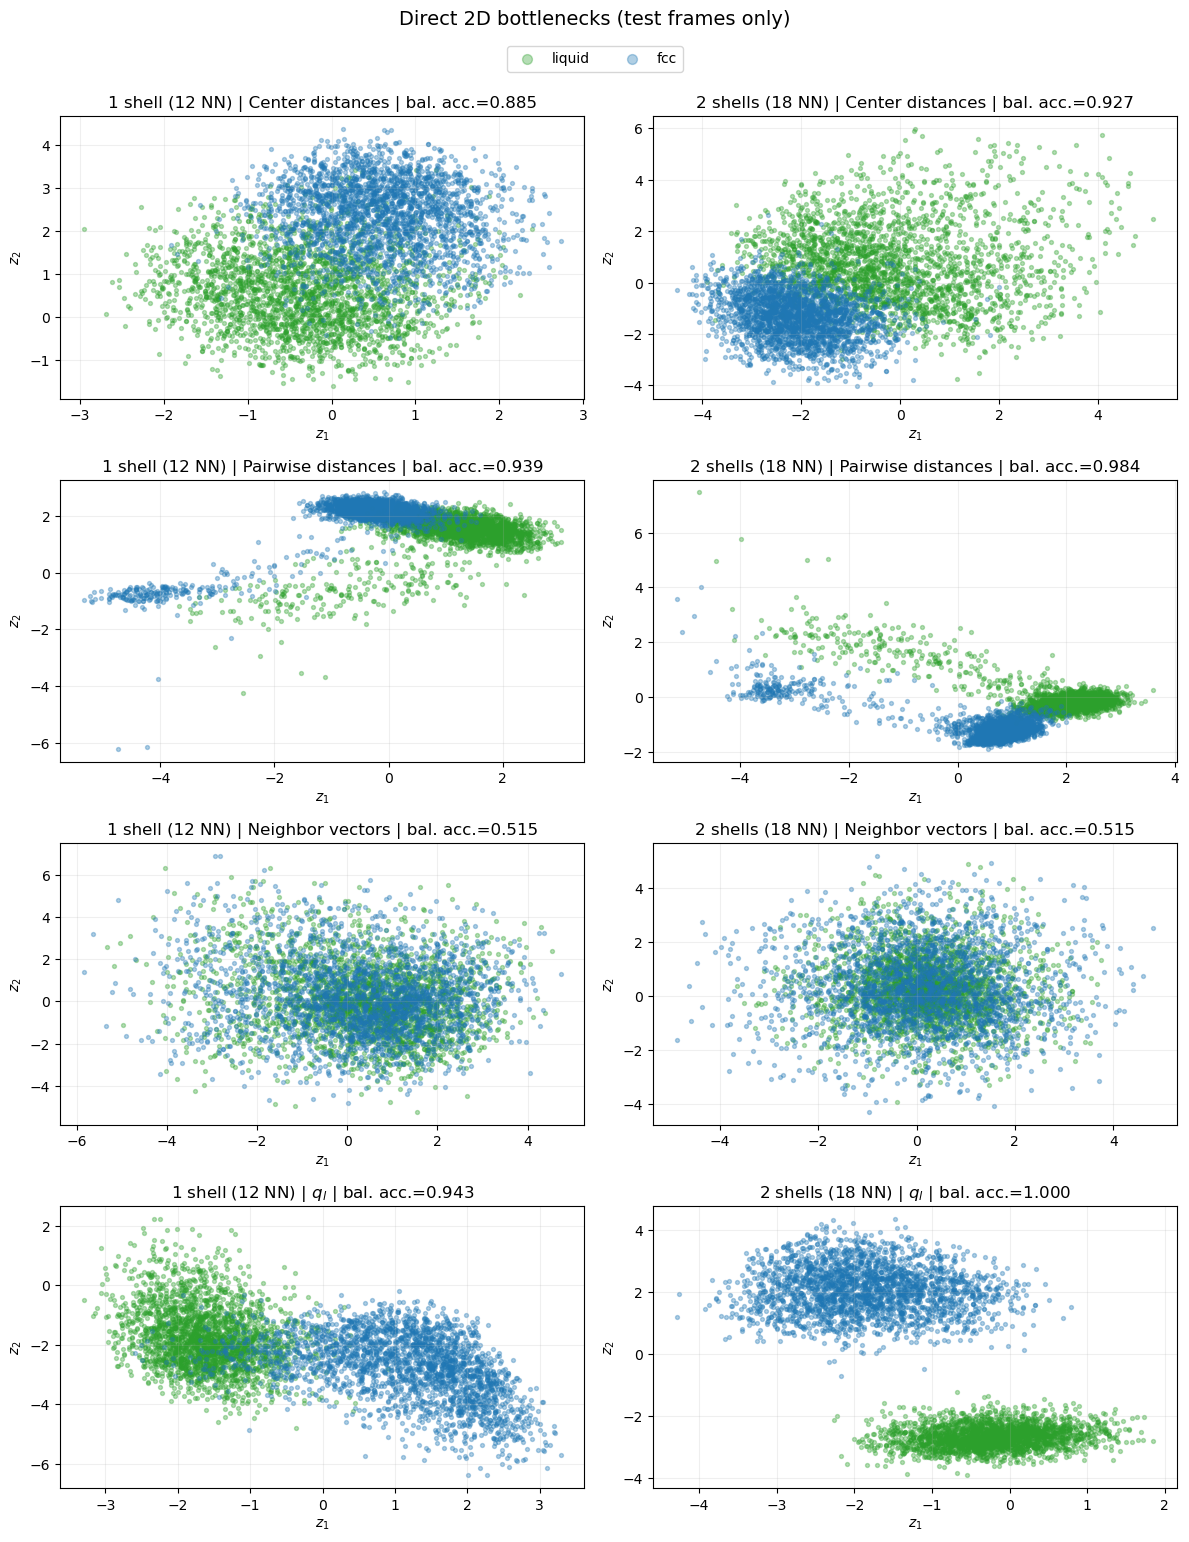

In [8]:
def plot_latent_grid(artifacts, split_to_plot="test"):
    fig, axes = plt.subplots(
        len(FEATURE_ORDER),
        len(SHELL_ORDER),
        figsize=(12, 15),
        squeeze=False,
    )
    rng = np.random.default_rng(VISUAL_SEED)

    for row, feature_kind in enumerate(FEATURE_ORDER):
        for col, shell_name in enumerate(SHELL_ORDER):
            ax = axes[row, col]
            artifact = artifacts[(shell_name, feature_kind)]
            Z, y, split = artifact["Z"], artifact["y"], artifact["split"]
            keep = split == split_to_plot

            for phase in PHASES:
                label = LABEL_MAP[phase]
                indices = np.flatnonzero(keep & (y == label))
                if len(indices) > MAX_PLOT_POINTS_PER_PHASE:
                    indices = rng.choice(
                        indices,
                        size=MAX_PLOT_POINTS_PER_PHASE,
                        replace=False,
                    )
                ax.scatter(
                    Z[indices, 0],
                    Z[indices, 1],
                    s=8,
                    alpha=0.35,
                    color=LABEL_COLORS[label],
                    label=phase,
                    rasterized=True,
                )

            score = artifact["probe"]["balanced_accuracy"]
            ax.set_title(
                f"{SHELL_CONFIG[shell_name]['label']} | "
                f"{FEATURE_LABELS[feature_kind]} | bal. acc.={score:.3f}"
            )
            ax.set_xlabel(r"$z_1$")
            ax.set_ylabel(r"$z_2$")
            ax.grid(alpha=0.2)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=2,
        bbox_to_anchor=(0.5, 1.005),
        markerscale=2.5,
    )
    fig.suptitle(
        f"Direct 2D bottlenecks ({split_to_plot} frames only)",
        y=1.025,
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()


plot_latent_grid(main_artifacts, split_to_plot="test")

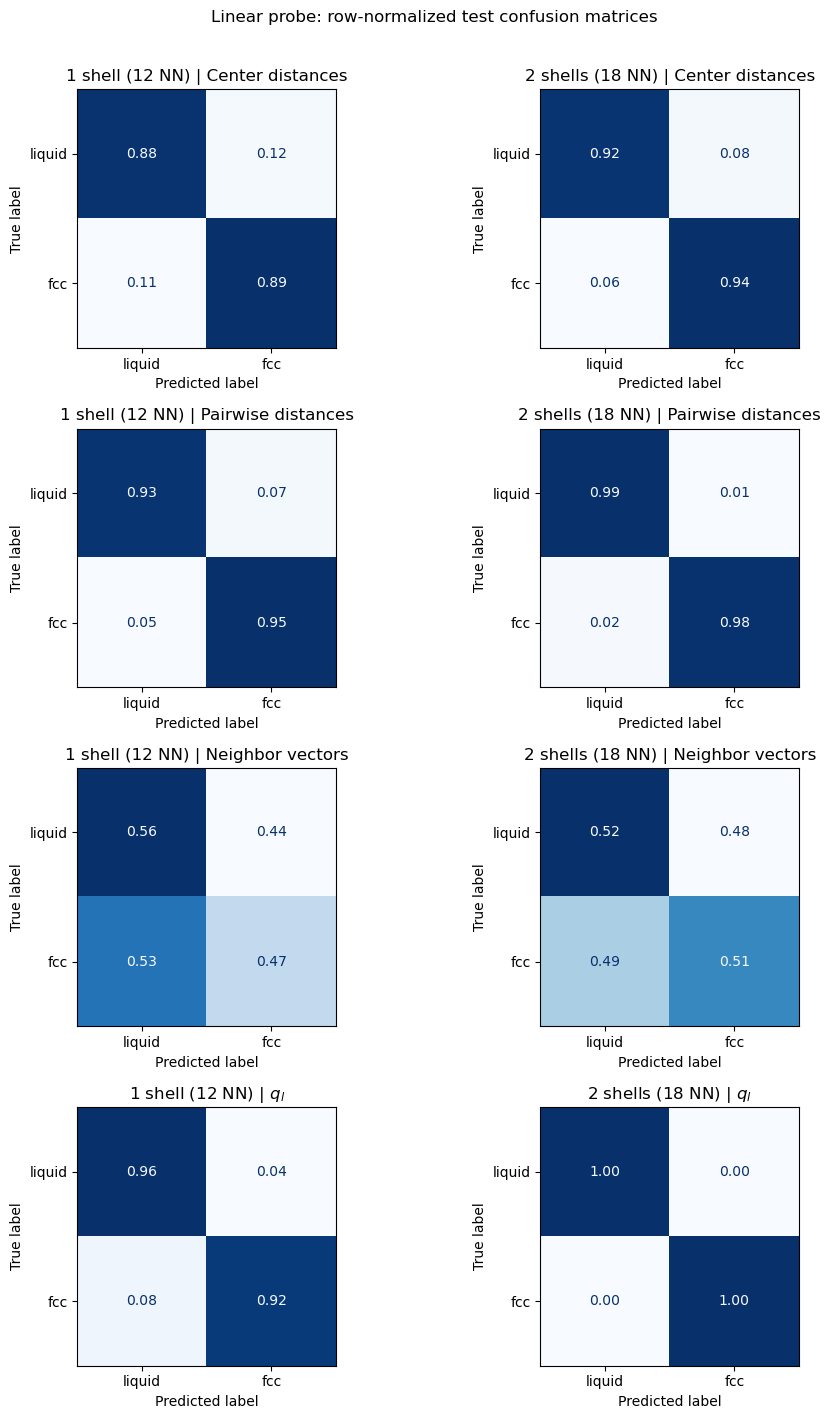

balanced_accuracy                         macro_f1  \
shell_label          1 shell (12 NN) 2 shells (18 NN) 1 shell (12 NN)   
feature_label                                                           
$q_l$                         0.9431           1.0000          0.9430   
Center distances              0.8847           0.9266          0.8847   
Neighbor vectors              0.5153           0.5151          0.5143   
Pairwise distances            0.9385           0.9836          0.9385   

                                            roc_auc                   
shell_label        2 shells (18 NN) 1 shell (12 NN) 2 shells (18 NN)  
feature_label                                                         
$q_l$                        1.0000          0.9806           1.0000  
Center distances             0.9266          0.9524           0.9780  
Neighbor vectors             0.5150          0.5202           0.5099  
Pairwise distances           0.9836          0.9834           0.9980

In [9]:
def plot_confusion_grid(artifacts):
    fig, axes = plt.subplots(
        len(FEATURE_ORDER),
        len(SHELL_ORDER),
        figsize=(10, 14),
        squeeze=False,
    )
    labels = [LABEL_MAP[phase] for phase in PHASES]
    names = [LABEL_NAMES[label] for label in labels]

    for row, feature_kind in enumerate(FEATURE_ORDER):
        for col, shell_name in enumerate(SHELL_ORDER):
            ax = axes[row, col]
            probe = artifacts[(shell_name, feature_kind)]["probe"]
            matrix = confusion_matrix(
                probe["y_test"],
                probe["y_pred"],
                labels=labels,
                normalize="true",
            )
            ConfusionMatrixDisplay(
                matrix,
                display_labels=names,
            ).plot(
                ax=ax,
                cmap="Blues",
                colorbar=False,
                values_format=".2f",
            )
            ax.set_title(
                f"{SHELL_CONFIG[shell_name]['label']} | "
                f"{FEATURE_LABELS[feature_kind]}"
            )
            ax.grid(False)

    fig.suptitle("Linear probe: row-normalized test confusion matrices", y=1.01)
    plt.tight_layout()
    plt.show()


plot_confusion_grid(main_artifacts)

main_metric_table = main_scores.pivot(
    index="feature_label",
    columns="shell_label",
    values=["balanced_accuracy", "macro_f1", "roc_auc"],
)
display(main_metric_table.round(4))

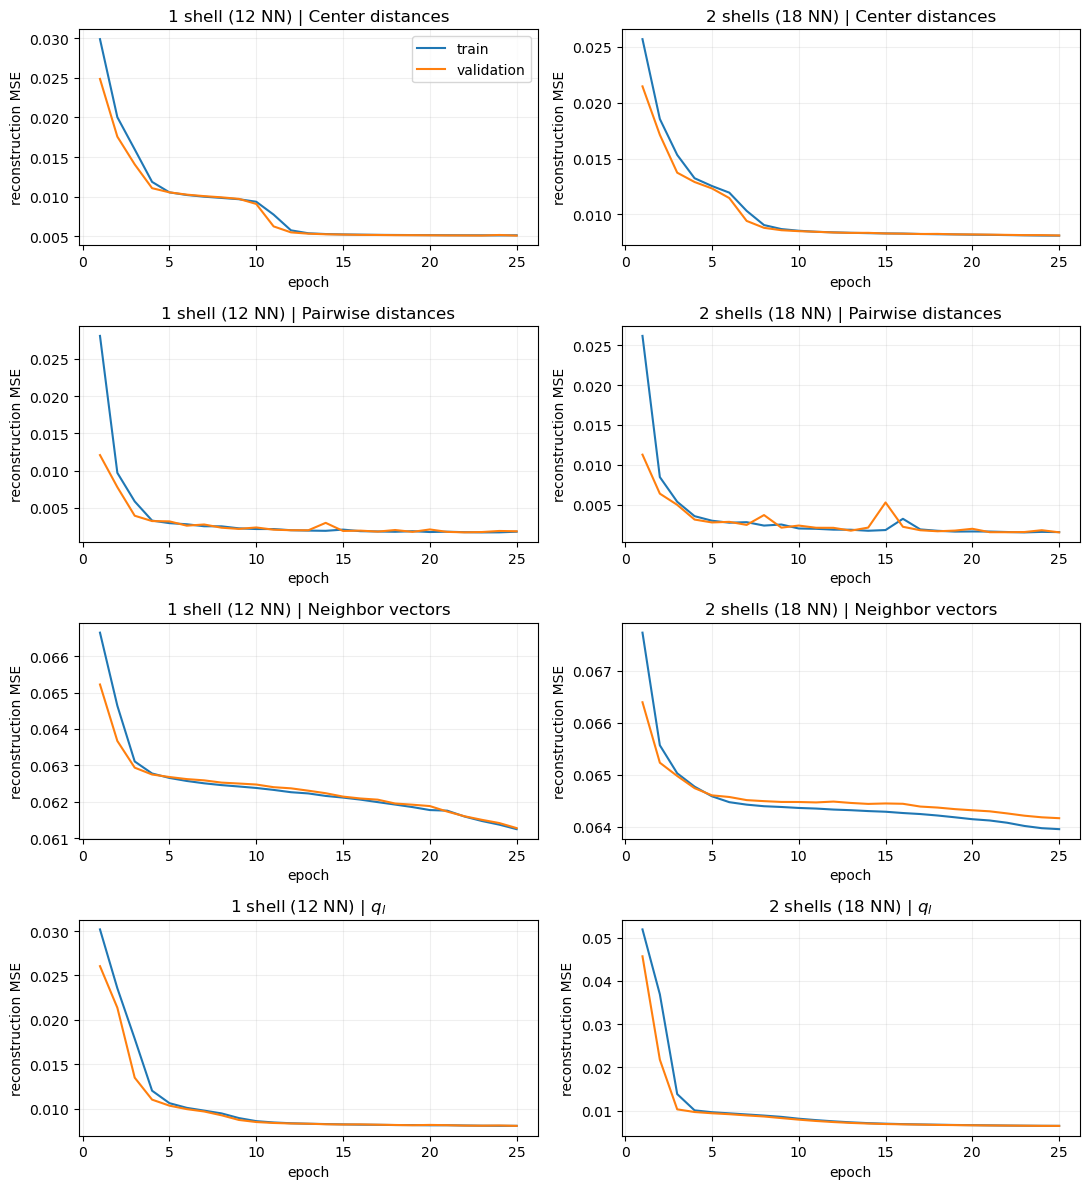

In [10]:
def plot_training_curves(artifacts):
    fig, axes = plt.subplots(
        len(FEATURE_ORDER),
        len(SHELL_ORDER),
        figsize=(11, 12),
        squeeze=False,
    )
    for row, feature_kind in enumerate(FEATURE_ORDER):
        for col, shell_name in enumerate(SHELL_ORDER):
            ax = axes[row, col]
            history = artifacts[(shell_name, feature_kind)]["history"]
            epochs = np.arange(1, len(history["train_mse"]) + 1)
            ax.plot(epochs, history["train_mse"], label="train")
            ax.plot(epochs, history["val_mse"], label="validation")
            ax.set_title(
                f"{SHELL_CONFIG[shell_name]['label']} | "
                f"{FEATURE_LABELS[feature_kind]}"
            )
            ax.set_xlabel("epoch")
            ax.set_ylabel("reconstruction MSE")
            ax.grid(alpha=0.2)
    axes[0, 0].legend()
    plt.tight_layout()
    plt.show()


plot_training_curves(main_artifacts)

### Robustness across 30 random seeds

The complete sampling → grouped split → training → encoding → probing pipeline is repeated 30 times. The visual seed is reused from the main run rather than trained twice. No plots are generated inside the repeat loop.

In [11]:
score_frames = [main_scores]
for seed in ROBUSTNESS_SEEDS:
    if seed == VISUAL_SEED:
        continue
    print(f"Robustness run for seed {seed}")
    seeded_scores, _, _ = run_suite(
        seed,
        keep_artifacts=False,
        verbose=False,
    )
    score_frames.append(seeded_scores)

robustness_scores = pd.concat(score_frames, ignore_index=True)
metric_names = ("accuracy", "balanced_accuracy", "macro_f1", "roc_auc")
robustness_summary = (
    robustness_scores
    .groupby(["feature_label", "shell_label"], sort=False)[list(metric_names)]
    .agg(["mean", "std", "min", "max"])
)
display(robustness_summary.round(4))

Robustness run for seed 0
Robustness run for seed 1
Robustness run for seed 2
Robustness run for seed 3
Robustness run for seed 4
Robustness run for seed 5
Robustness run for seed 6
Robustness run for seed 7
Robustness run for seed 8
Robustness run for seed 9
Robustness run for seed 10
Robustness run for seed 11
Robustness run for seed 12
Robustness run for seed 13
Robustness run for seed 14
Robustness run for seed 15
Robustness run for seed 16
Robustness run for seed 17
Robustness run for seed 18
Robustness run for seed 19
Robustness run for seed 20
Robustness run for seed 21
Robustness run for seed 22
Robustness run for seed 23
Robustness run for seed 24
Robustness run for seed 25
Robustness run for seed 26
Robustness run for seed 27
Robustness run for seed 28


accuracy                          \
                                        mean     std     min     max   
feature_label      shell_label                                         
Center distances   1 shell (12 NN)    0.8853  0.0046  0.8710  0.8936   
Pairwise distances 1 shell (12 NN)    0.9155  0.0371  0.7800  0.9387   
Neighbor vectors   1 shell (12 NN)    0.5036  0.0078  0.4844  0.5178   
$q_l$              1 shell (12 NN)    0.9464  0.0050  0.9315  0.9565   
Center distances   2 shells (18 NN)   0.9242  0.0039  0.9169  0.9299   
Pairwise distances 2 shells (18 NN)   0.9816  0.0019  0.9782  0.9871   
Neighbor vectors   2 shells (18 NN)   0.5051  0.0097  0.4860  0.5261   
$q_l$              2 shells (18 NN)   0.9999  0.0001  0.9996  1.0000   

                                    balanced_accuracy                          \
                                                 mean     std     min     max   
feature_label      shell_label                                                  
Center distances   1 shell (12 NN)             0.8853  0.0046  0.8709  0.8935   
Pairwise distances 1 shell (12 NN)             0.9155  0.0370  0.7803  0.9387   
Neighbor vectors   1 shell (12 NN)             0.5036  0.0079  0.4847  0.5181   
$q_l$              1 shell (12 NN)             0.9464  0.0049  0.9317  0.9564   
Center distances   2 shells (18 NN)            0.9242  0.0039  0.9168  0.9298   
Pairwise distances 2 shells (18 NN)            0.9816  0.0019  0.9782  0.9871   
Neighbor vectors   2 shells (18 NN)            0.5050  0.0096  0.4860  0.5262   
$q_l$              2 shells (18 NN)            0.9999  0.0001  0.9996  1.0000   

                                    macro_f1                         roc_auc  \
                                        mean     std     min     max    mean   
feature_label      shell_label                                                 
Center distances   1 shell (12 NN)    0.8853  0.0046  0.8710  0.8936  0.9535   
Pairwise distances 1 shell (12 NN)    0.9155  0.0371  0.7799  0.9387  0.9652   
Neighbor vectors   1 shell (12 NN)    0.5031  0.0078  0.4840  0.5173  0.5055   
$q_l$              1 shell (12 NN)    0.9463  0.0050  0.9315  0.9565  0.9828   
Center distances   2 shells (18 NN)   0.9242  0.0039  0.9168  0.9299  0.9774   
Pairwise distances 2 shells (18 NN)   0.9815  0.0019  0.9782  0.9871  0.9968   
Neighbor vectors   2 shells (18 NN)   0.5047  0.0096  0.4860  0.5255  0.5053   
$q_l$              2 shells (18 NN)   0.9999  0.0001  0.9996  1.0000  1.0000   

                                                             
                                        std     min     max  
feature_label      shell_label                               
Center distances   1 shell (12 NN)   0.0027  0.9466  0.9586  
Pairwise distances 1 shell (12 NN)   0.0344  0.8312  0.9839  
Neighbor vectors   1 shell (12 NN)   0.0089  0.4767  0.5202  
$q_l$              1 shell (12 NN)   0.0023  0.9778  0.9876  
Center distances   2 shells (18 NN)  0.0013  0.9747  0.9803  
Pairwise distances 2 shells (18 NN)  0.0010  0.9949  0.9984  
Neighbor vectors   2 shells (18 NN)  0.0102  0.4888  0.5304  
$q_l$              2 shells (18 NN)  0.0000  1.0000  1.0000

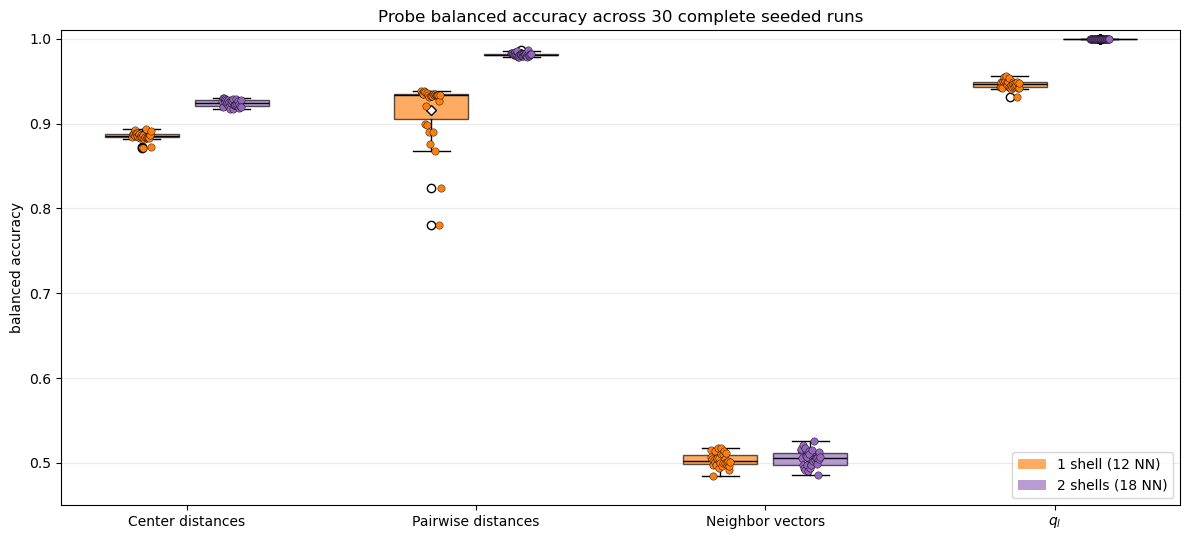

mean                              std  \
shell_label        1 shell (12 NN) 2 shells (18 NN) 1 shell (12 NN)   
feature_label                                                         
$q_l$                       0.9464           0.9999          0.0049   
Center distances            0.8853           0.9242          0.0046   
Neighbor vectors            0.5036           0.5050          0.0079   
Pairwise distances          0.9155           0.9816          0.0370   

                                     
shell_label        2 shells (18 NN)  
feature_label                        
$q_l$                        0.0001  
Center distances             0.0039  
Neighbor vectors             0.0096  
Pairwise distances           0.0019

In [12]:
def plot_robustness_boxplots(scores, metric="balanced_accuracy"):
    fig, ax = plt.subplots(figsize=(12, 5.5))
    shell_colors = {
        "first_shell": "tab:orange",
        "second_shell": "tab:purple",
    }
    offsets = {"first_shell": -0.28, "second_shell": 0.28}
    centers = np.arange(len(FEATURE_ORDER)) * 1.8
    width = 0.46

    for shell_name in SHELL_ORDER:
        values = [
            scores.loc[
                (scores["feature"] == feature_kind)
                & (scores["shell"] == shell_name),
                metric,
            ].to_numpy()
            for feature_kind in FEATURE_ORDER
        ]
        positions = centers + offsets[shell_name]
        boxes = ax.boxplot(
            values,
            positions=positions,
            widths=width,
            patch_artist=True,
            showmeans=True,
            meanprops={
                "marker": "D",
                "markerfacecolor": "white",
                "markeredgecolor": "black",
                "markersize": 5,
            },
            medianprops={"color": "black"},
        )
        for box in boxes["boxes"]:
            box.set_facecolor(shell_colors[shell_name])
            box.set_alpha(0.65)

        # Show every run, not only the box summary.
        for position, feature_values in zip(positions, values):
            jitter = np.linspace(-0.06, 0.06, len(feature_values))
            ax.scatter(
                position + jitter,
                feature_values,
                color=shell_colors[shell_name],
                edgecolor="black",
                linewidth=0.3,
                s=28,
                zorder=3,
            )

    ax.set_xticks(centers)
    ax.set_xticklabels([FEATURE_LABELS[k] for k in FEATURE_ORDER])
    ax.set_ylabel(metric.replace("_", " "))
    ax.set_ylim(0.45, 1.01)
    ax.set_title(
        f"Probe {metric.replace('_', ' ')} across "
        f"{scores['seed'].nunique()} complete seeded runs"
    )
    ax.grid(axis="y", alpha=0.25)
    ax.legend(
        handles=[
            Patch(
                facecolor=shell_colors[shell_name],
                alpha=0.65,
                label=SHELL_CONFIG[shell_name]["label"],
            )
            for shell_name in SHELL_ORDER
        ],
        loc="lower right",
    )
    plt.tight_layout()
    plt.show()


plot_robustness_boxplots(robustness_scores, metric="balanced_accuracy")

mean_std_table = robustness_scores.pivot_table(
    index="feature_label",
    columns="shell_label",
    values="balanced_accuracy",
    aggfunc=["mean", "std"],
)
display(mean_std_table.round(4))

### Liquid–FCC ranking and interpretation

Balanced accuracy is the primary comparison because it gives both phases equal weight. Macro-F1 and ROC-AUC are useful checks. Reconstruction MSE is not a phase-separation metric: a low reconstruction error can coexist with a poorly separable bottleneck.

Expected qualitative behavior:

- Center and pairwise distances have strong rotation/permutation invariance built into the input.
- Raw vectors are translation invariant but not rotation invariant; radial sorting is unstable when neighbor distances are nearly tied. A weak or variable probe score is informative rather than a pipeline failure.
- $q_l$ inputs encode rotational invariance explicitly. Interpret second-shell $q_l$ as a true 18-neighbor comparison only when `q_l_exact_requested_NN` is true in the data table.
- Seed distributions combine variation from sampling, frame splits, mini-batch ordering, and initialization. They are not uncertainty estimates over independently generated thermodynamic trajectories.

In [13]:
ranking = (
    robustness_scores
    .groupby(["feature_label", "shell_label"], as_index=False)
    .agg(
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        std_balanced_accuracy=("balanced_accuracy", "std"),
        mean_macro_f1=("macro_f1", "mean"),
        mean_roc_auc=("roc_auc", "mean"),
        runs=("seed", "nunique"),
    )
    .sort_values("mean_balanced_accuracy", ascending=False)
    .reset_index(drop=True)
)
display(ranking.round(4))

,feature_label,shell_label,mean_balanced_accuracy,std_balanced_accuracy,mean_macro_f1,mean_roc_auc,runs
0,$q_l$,2 shells (18 NN),0.9999,0.0001,0.9999,1.0000,30
1,Pairwise distances,2 shells (18 NN),0.9816,0.0019,0.9815,0.9968,30
2,$q_l$,1 shell (12 NN),0.9464,0.0049,0.9463,0.9828,30
3,Center distances,2 shells (18 NN),0.9242,0.0039,0.9242,0.9774,30
4,Pairwise distances,1 shell (12 NN),0.9155,0.0370,0.9155,0.9652,30
5,Center distances,1 shell (12 NN),0.8853,0.0046,0.8853,0.9535,30
6,Neighbor vectors,2 shells (18 NN),0.5050,0.0096,0.5047,0.5053,30
7,Neighbor vectors,1 shell (12 NN),0.5036,0.0079,0.5031,0.5055,30


## Part II — FCC vs HCP: where the simple autoencoder reaches its limit

FCC and HCP have the same 12-fold first coordination shell and differ primarily in stacking beyond it. This makes the comparison substantially harder and makes the first-versus-second-shell contrast physically meaningful.

The vector input is removed. In its place, **triplets** are the angles $\theta_{jik}$ formed by the central particle $i$ and every unordered pair of neighbors $(j,k)$. The sorted angle signature contains $\binom{12}{2}=66$ values for the first shell and $\binom{18}{2}=153$ for the second. It is invariant to global translation, rotation, and neighbor permutation. Sorting intentionally discards which radial pair produced each angle, so this remains a compact baseline rather than a full three-body correlation representation.

In [14]:
FCC_HCP_PHASES = ("fcc", "hcp")
FCC_HCP_LABEL_MAP = {"fcc": 0, "hcp": 1}
FCC_HCP_LABEL_NAMES = {0: "fcc", 1: "hcp"}
FCC_HCP_LABEL_COLORS = {0: "tab:blue", 1: "tab:orange"}
FCC_HCP_FEATURE_ORDER = ("radii", "pairwise_distances", "triplets", "ql")
FCC_HCP_FEATURE_LABELS = {
    "radii": "Center distances",
    "pairwise_distances": "Pairwise distances",
    "triplets": "Central triplet angles",
    "ql": r"$q_l$",
}

fcc_hcp_shell_data = {shell_name: {} for shell_name in SHELL_ORDER}
fcc_hcp_summary_rows = []

for shell_name, shell_cfg in SHELL_CONFIG.items():
    # Reuse the already loaded FCC arrays and load HCP with the same conventions.
    fcc_hcp_shell_data[shell_name]["fcc"] = shell_data[shell_name]["fcc"]
    hcp_path = _resolve_shell_file("hcp", shell_name)
    hcp_data = load_particle_data(hcp_path, shell_cfg["ql_key"])
    expected_nn = shell_cfg["n_neighbors"]
    if hcp_data["dist"].shape[1] != expected_nn or hcp_data["vec_dist"].shape[1] != expected_nn:
        raise ValueError(
            f"{hcp_path}: expected {expected_nn} geometric neighbors, "
            f"got dist={hcp_data['dist'].shape[1]} and vec={hcp_data['vec_dist'].shape[1]}"
        )
    hcp_data["ql_exact"] = hcp_data["descriptor_nn"] == expected_nn
    if not hcp_data["ql_exact"]:
        warnings.warn(
            f"{hcp_path.name} (hcp): q_l used {hcp_data['descriptor_nn']} neighbors, "
            f"not the requested {expected_nn}.",
            stacklevel=2,
        )
    fcc_hcp_shell_data[shell_name]["hcp"] = hcp_data

    for phase in FCC_HCP_PHASES:
        data = fcc_hcp_shell_data[shell_name][phase]
        fcc_hcp_summary_rows.append(
            {
                "shell": shell_cfg["label"],
                "phase": phase,
                "file": data["source"].name,
                "samples": len(data["dist"]),
                "geometric_NN": data["dist"].shape[1],
                "q_l_variant": shell_cfg["ql_variant"],
                "q_l_descriptor_NN": data["descriptor_nn"],
                "q_l_exact_requested_NN": data["ql_exact"],
            }
        )

first_hcp = fcc_hcp_shell_data["first_shell"]["hcp"]
second_hcp = fcc_hcp_shell_data["second_shell"]["hcp"]
if not np.array_equal(first_hcp["picked_ids"], second_hcp["picked_ids"]):
    raise ValueError("Picked HCP particle IDs differ between shells.")
if not np.array_equal(first_hcp["frame_indices"], second_hcp["frame_indices"]):
    raise ValueError("HCP frame indices differ between shells.")

display(pd.DataFrame(fcc_hcp_summary_rows))

/home/jakob/miniconda3/envs/autoencode-statmech/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3579: UserWarning: particle_data_second_shell.npz (hcp): q_l used 12 neighbors, not the requested 18.
  exec(code_obj, self.user_global_ns, self.user_ns)


,shell,phase,file,samples,geometric_NN,q_l_variant,q_l_descriptor_NN,q_l_exact_requested_NN
0,1 shell (12 NN),fcc,particle_data.npz,180300,12,standard,12,True
1,1 shell (12 NN),hcp,particle_data.npz,180300,12,standard,12,True
2,2 shells (18 NN),fcc,particle_data_second_shell.npz,180300,18,Lechner-Dellago averaged,12,False
3,2 shells (18 NN),hcp,particle_data_second_shell.npz,180300,18,Lechner-Dellago averaged,12,False


In [15]:
def triplet_angle_features(vectors, chunk_size=PAIRWISE_CHUNK_SIZE):
    """Sorted central bond angles for all unordered neighbor pairs."""
    n_samples, n_neighbors, _ = vectors.shape
    pair_i, pair_j = np.triu_indices(n_neighbors, k=1)
    output = np.empty((n_samples, len(pair_i)), dtype=np.float32)

    for start in range(0, n_samples, chunk_size):
        stop = min(start + chunk_size, n_samples)
        chunk = vectors[start:stop]
        norms = np.linalg.norm(chunk, axis=2, keepdims=True)
        unit = chunk / np.maximum(norms, 1e-12)
        cosine = np.einsum(
            "bpc,bpc->bp",
            unit[:, pair_i, :],
            unit[:, pair_j, :],
        )
        output[start:stop] = np.arccos(np.clip(cosine, -1.0, 1.0))

    output.sort(axis=1)
    return output


def build_fcc_hcp_feature(data, feature_kind, indices):
    if feature_kind == "triplets":
        return triplet_angle_features(data["vec_dist"][indices])
    return build_feature(data, feature_kind, indices)


def build_fcc_hcp_sampling_plan(seed):
    rng = np.random.default_rng(seed)
    reference = fcc_hcp_shell_data["first_shell"]
    n_per_phase = min(
        MAX_SAMPLES_PER_PHASE,
        *(len(reference[phase]["dist"]) for phase in FCC_HCP_PHASES),
    )
    plan = {}
    for phase in FCC_HCP_PHASES:
        data = reference[phase]
        indices = np.sort(rng.choice(len(data["dist"]), size=n_per_phase, replace=False))
        split = _frame_split(data["frame_indices"][indices], rng)
        plan[phase] = {"indices": indices, "split": split}
    return plan


def prepare_fcc_hcp_experiment(shell_name, feature_kind, plan):
    X_parts, y_parts, split_parts = [], [], []
    for phase in FCC_HCP_PHASES:
        entry = plan[phase]
        X_parts.append(
            build_fcc_hcp_feature(
                fcc_hcp_shell_data[shell_name][phase],
                feature_kind,
                entry["indices"],
            )
        )
        y_parts.append(
            np.full(len(entry["indices"]), FCC_HCP_LABEL_MAP[phase], dtype=np.int64)
        )
        split_parts.append(entry["split"])
    return (
        np.concatenate(X_parts).astype(np.float32, copy=False),
        np.concatenate(y_parts),
        np.concatenate(split_parts),
    )


fcc_hcp_example_plan = build_fcc_hcp_sampling_plan(VISUAL_SEED)
fcc_hcp_plan_rows = []
for phase in FCC_HCP_PHASES:
    entry = fcc_hcp_example_plan[phase]
    frames = fcc_hcp_shell_data["first_shell"][phase]["frame_indices"][entry["indices"]]
    for partition in ("train", "val", "test"):
        mask = entry["split"] == partition
        fcc_hcp_plan_rows.append(
            {
                "phase": phase,
                "partition": partition,
                "particles": int(mask.sum()),
                "frames": int(np.unique(frames[mask]).size),
            }
        )
display(pd.DataFrame(fcc_hcp_plan_rows))

,phase,partition,particles,frames
0,fcc,train,7276,361
1,fcc,val,2416,120
2,fcc,test,2308,120
3,hcp,train,7090,361
4,hcp,val,2489,120
5,hcp,test,2421,120


In [16]:
def run_fcc_hcp_suite(seed, keep_artifacts=True, verbose=True):
    plan = build_fcc_hcp_sampling_plan(seed)
    rows = []
    artifacts = {}

    for shell_name in SHELL_ORDER:
        shell_cfg = SHELL_CONFIG[shell_name]
        ql_exact = all(
            fcc_hcp_shell_data[shell_name][phase]["ql_exact"]
            for phase in FCC_HCP_PHASES
        )
        for feature_kind in FCC_HCP_FEATURE_ORDER:
            if verbose:
                print(
                    f"seed={seed:>3} | {shell_cfg['label']:<18} | "
                    f"{FCC_HCP_FEATURE_LABELS[feature_kind]}"
                )
            X, y, split = prepare_fcc_hcp_experiment(shell_name, feature_kind, plan)
            ae = train_autoencoder(X, split, seed)
            probe = probe_latent(ae["Z"], y, split, seed)

            rows.append(
                {
                    "seed": seed,
                    "shell": shell_name,
                    "shell_label": shell_cfg["label"],
                    "n_neighbors": shell_cfg["n_neighbors"],
                    "feature": feature_kind,
                    "feature_label": FCC_HCP_FEATURE_LABELS[feature_kind],
                    "input_dim": X.shape[1],
                    "n_samples": len(X),
                    "best_epoch": ae["best_epoch"],
                    "validation_mse": ae["best_val_mse"],
                    "accuracy": probe["accuracy"],
                    "balanced_accuracy": probe["balanced_accuracy"],
                    "macro_f1": probe["macro_f1"],
                    "roc_auc": probe["roc_auc"],
                    "q_l_exact_requested_NN": ql_exact if feature_kind == "ql" else pd.NA,
                }
            )
            if keep_artifacts:
                artifacts[(shell_name, feature_kind)] = {
                    "Z": ae["Z"],
                    "y": y,
                    "split": split,
                    "history": ae["history"],
                    "model": ae["model"],
                    "scaler": ae["scaler"],
                    "probe": probe,
                }

            del X, ae
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    return pd.DataFrame(rows), artifacts, plan

### FCC vs HCP main run

In [17]:
fcc_hcp_main_scores, fcc_hcp_main_artifacts, fcc_hcp_main_plan = run_fcc_hcp_suite(
    VISUAL_SEED,
    keep_artifacts=True,
    verbose=True,
)

display(
    fcc_hcp_main_scores[score_columns]
    .sort_values(["feature_label", "shell_label"])
    .reset_index(drop=True)
    .round(4)
)

seed= 42 | 1 shell (12 NN)    | Center distances
seed= 42 | 1 shell (12 NN)    | Pairwise distances
seed= 42 | 1 shell (12 NN)    | Central triplet angles
seed= 42 | 1 shell (12 NN)    | $q_l$
seed= 42 | 2 shells (18 NN)   | Center distances
seed= 42 | 2 shells (18 NN)   | Pairwise distances
seed= 42 | 2 shells (18 NN)   | Central triplet angles
seed= 42 | 2 shells (18 NN)   | $q_l$


,shell_label,feature_label,input_dim,best_epoch,validation_mse,accuracy,balanced_accuracy,macro_f1,roc_auc,q_l_exact_requested_NN
0,1 shell (12 NN),$q_l$,20,25,0.0065,0.9695,0.9692,0.9695,0.9802,True
1,2 shells (18 NN),$q_l$,20,25,0.0061,0.9987,0.9987,0.9987,1.0000,False
2,1 shell (12 NN),Center distances,12,25,0.0063,0.5100,0.5095,0.5095,0.5086,<NA>
3,2 shells (18 NN),Center distances,18,25,0.0095,0.5062,0.5055,0.5053,0.5054,<NA>
4,1 shell (12 NN),Central triplet angles,66,25,0.0016,0.6779,0.6794,0.6773,0.7468,<NA>
5,2 shells (18 NN),Central triplet angles,153,25,0.0011,0.8465,0.8447,0.8451,0.8588,<NA>
6,1 shell (12 NN),Pairwise distances,78,23,0.0014,0.5077,0.5077,0.5076,0.5142,<NA>
7,2 shells (18 NN),Pairwise distances,171,24,0.0017,0.8972,0.8971,0.8972,0.9446,<NA>


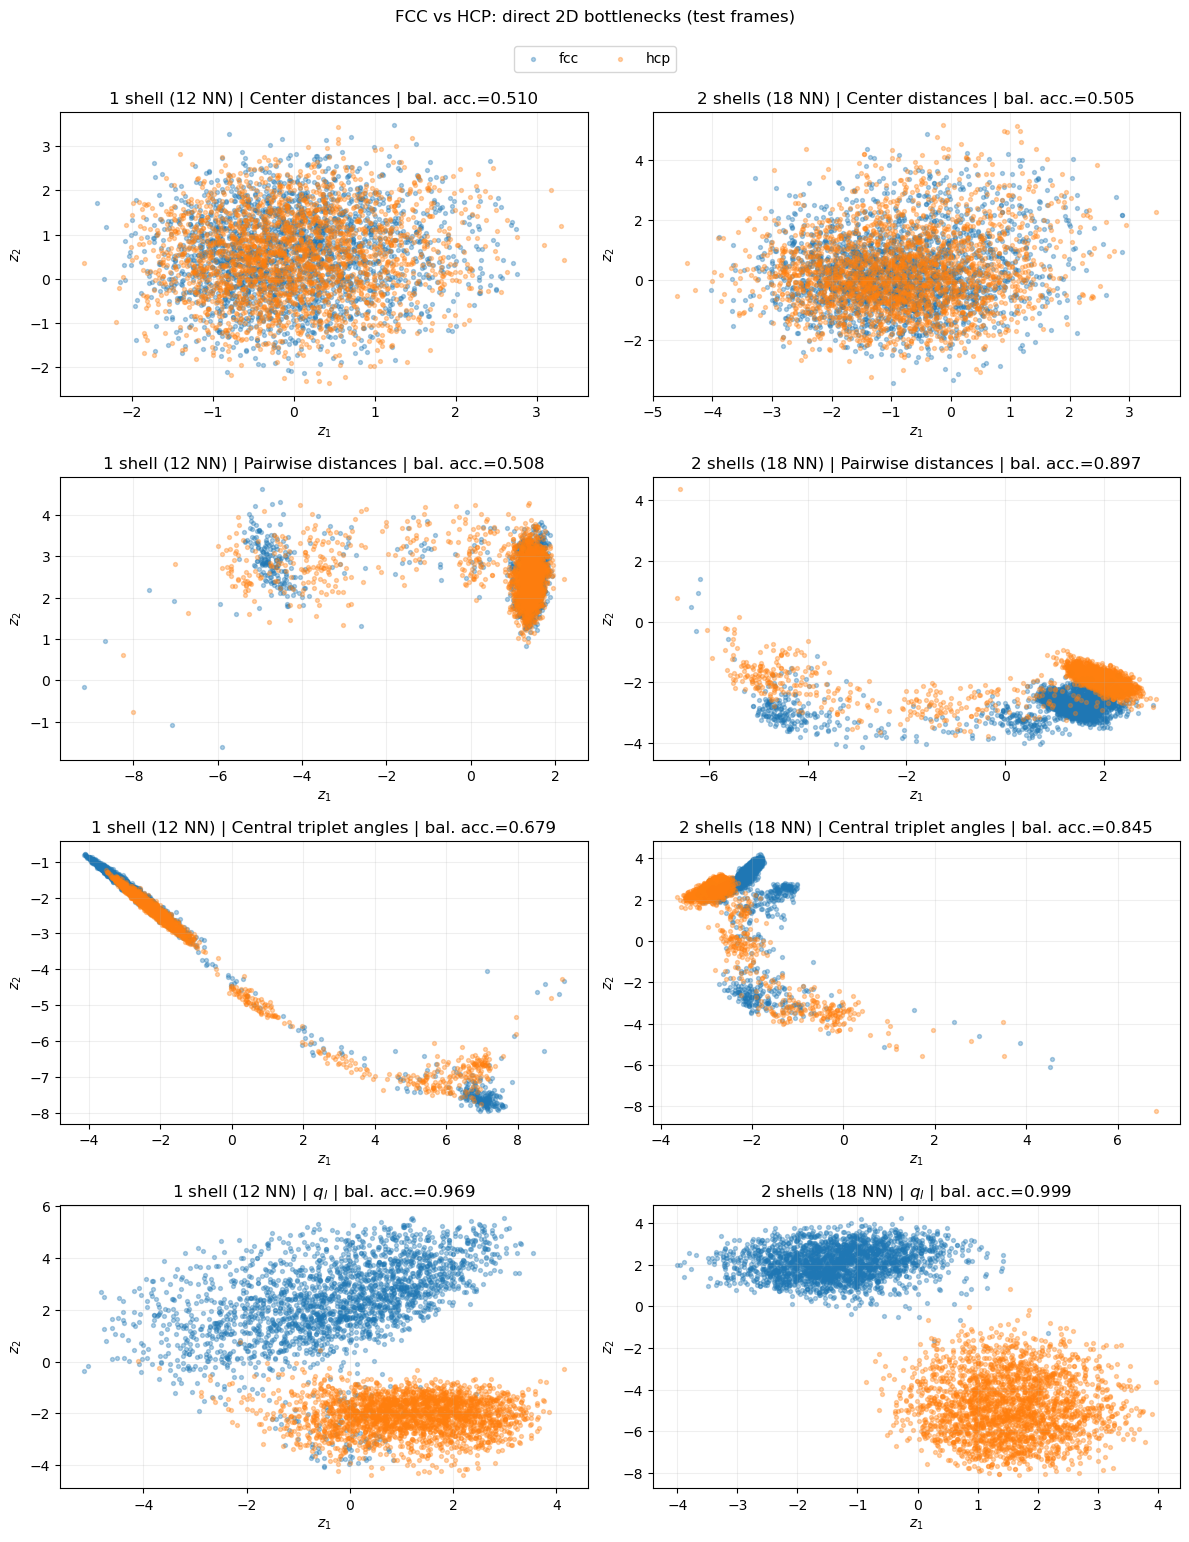

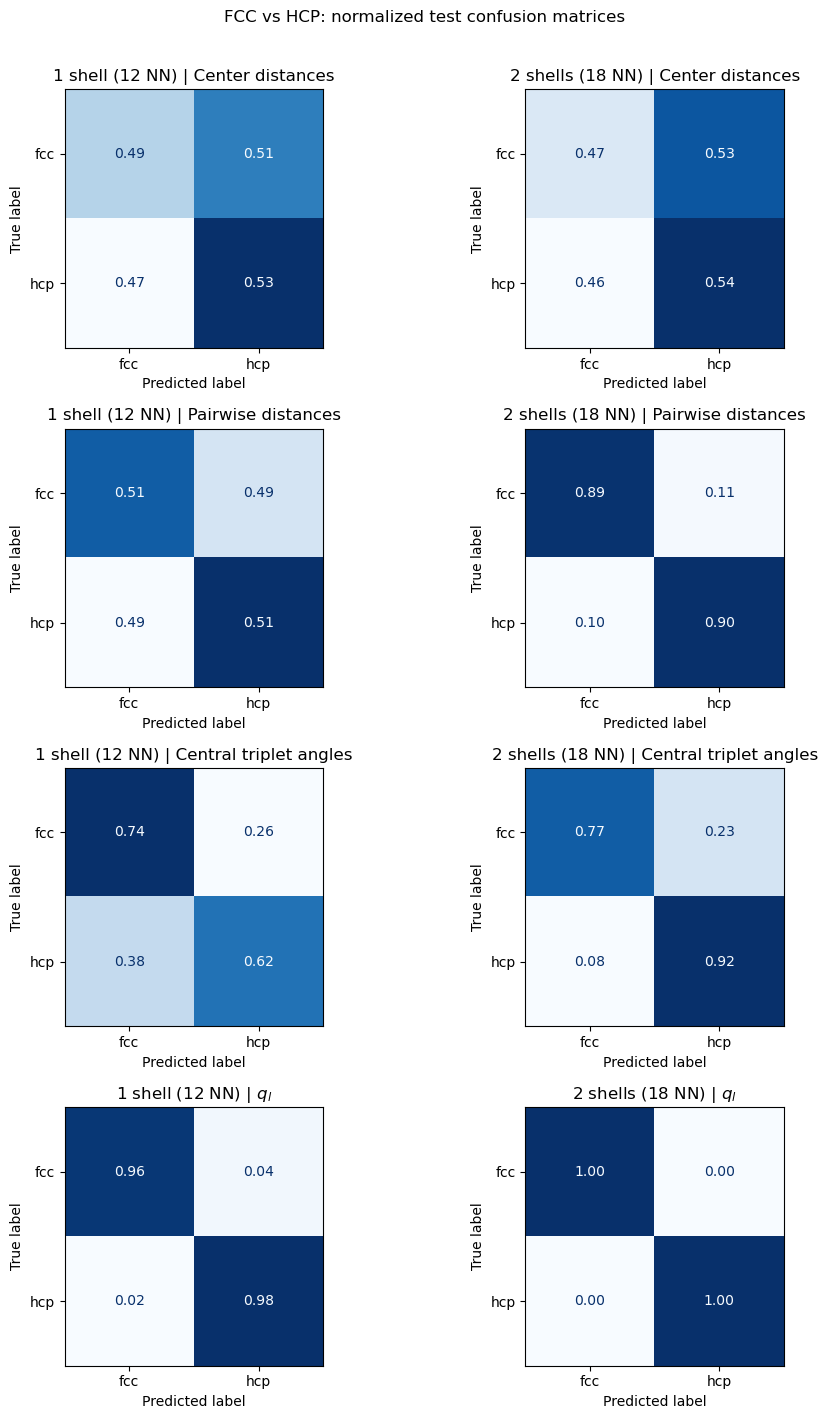

balanced_accuracy                         macro_f1  \
shell_label              1 shell (12 NN) 2 shells (18 NN) 1 shell (12 NN)   
feature_label                                                               
$q_l$                             0.9692           0.9987          0.9695   
Center distances                  0.5095           0.5055          0.5095   
Central triplet angles            0.6794           0.8447          0.6773   
Pairwise distances                0.5077           0.8971          0.5076   

                                                roc_auc                   
shell_label            2 shells (18 NN) 1 shell (12 NN) 2 shells (18 NN)  
feature_label                                                             
$q_l$                            0.9987          0.9802           1.0000  
Center distances                 0.5053          0.5086           0.5054  
Central triplet angles           0.8451          0.7468           0.8588  
Pairwise distances               0.8972          0.5142           0.9446

In [18]:
def plot_binary_latent_grid(
    artifacts,
    feature_order,
    feature_labels,
    phases,
    label_map,
    label_colors,
    comparison_title,
    split_to_plot="test",
):
    fig, axes = plt.subplots(
        len(feature_order),
        len(SHELL_ORDER),
        figsize=(12, 15),
        squeeze=False,
    )
    rng = np.random.default_rng(VISUAL_SEED)

    for row, feature_kind in enumerate(feature_order):
        for col, shell_name in enumerate(SHELL_ORDER):
            ax = axes[row, col]
            artifact = artifacts[(shell_name, feature_kind)]
            Z, y, split = artifact["Z"], artifact["y"], artifact["split"]
            keep = split == split_to_plot
            for phase in phases:
                label = label_map[phase]
                indices = np.flatnonzero(keep & (y == label))
                if len(indices) > MAX_PLOT_POINTS_PER_PHASE:
                    indices = rng.choice(indices, MAX_PLOT_POINTS_PER_PHASE, replace=False)
                ax.scatter(
                    Z[indices, 0],
                    Z[indices, 1],
                    s=8,
                    alpha=0.35,
                    color=label_colors[label],
                    label=phase,
                    rasterized=True,
                )
            score = artifact["probe"]["balanced_accuracy"]
            ax.set_title(
                f"{SHELL_CONFIG[shell_name]['label']} | "
                f"{feature_labels[feature_kind]} | bal. acc.={score:.3f}"
            )
            ax.set_xlabel(r"$z_1$")
            ax.set_ylabel(r"$z_2$")
            ax.grid(alpha=0.2)

    handles, legend_labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, legend_labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.005))
    fig.suptitle(f"{comparison_title}: direct 2D bottlenecks ({split_to_plot} frames)", y=1.025)
    plt.tight_layout()
    plt.show()


def plot_binary_confusion_grid(
    artifacts,
    feature_order,
    feature_labels,
    phases,
    label_map,
    label_names,
    comparison_title,
):
    fig, axes = plt.subplots(
        len(feature_order),
        len(SHELL_ORDER),
        figsize=(10, 14),
        squeeze=False,
    )
    labels = [label_map[phase] for phase in phases]
    names = [label_names[label] for label in labels]
    for row, feature_kind in enumerate(feature_order):
        for col, shell_name in enumerate(SHELL_ORDER):
            ax = axes[row, col]
            probe = artifacts[(shell_name, feature_kind)]["probe"]
            matrix = confusion_matrix(
                probe["y_test"],
                probe["y_pred"],
                labels=labels,
                normalize="true",
            )
            ConfusionMatrixDisplay(matrix, display_labels=names).plot(
                ax=ax,
                cmap="Blues",
                colorbar=False,
                values_format=".2f",
            )
            ax.set_title(
                f"{SHELL_CONFIG[shell_name]['label']} | {feature_labels[feature_kind]}"
            )
            ax.grid(False)
    fig.suptitle(f"{comparison_title}: normalized test confusion matrices", y=1.01)
    plt.tight_layout()
    plt.show()


plot_binary_latent_grid(
    fcc_hcp_main_artifacts,
    FCC_HCP_FEATURE_ORDER,
    FCC_HCP_FEATURE_LABELS,
    FCC_HCP_PHASES,
    FCC_HCP_LABEL_MAP,
    FCC_HCP_LABEL_COLORS,
    "FCC vs HCP",
)
plot_binary_confusion_grid(
    fcc_hcp_main_artifacts,
    FCC_HCP_FEATURE_ORDER,
    FCC_HCP_FEATURE_LABELS,
    FCC_HCP_PHASES,
    FCC_HCP_LABEL_MAP,
    FCC_HCP_LABEL_NAMES,
    "FCC vs HCP",
)

fcc_hcp_metric_table = fcc_hcp_main_scores.pivot(
    index="feature_label",
    columns="shell_label",
    values=["balanced_accuracy", "macro_f1", "roc_auc"],
)
display(fcc_hcp_metric_table.round(4))

### FCC vs HCP robustness across 30 random seeds

As above, the visual seed is one of the 30 complete runs and is reused. Each other seed resamples particles, constructs new frame-grouped partitions, initializes a new autoencoder, and refits the probe. No per-seed plots are created.

In [19]:
fcc_hcp_score_frames = [fcc_hcp_main_scores]
for seed in ROBUSTNESS_SEEDS:
    if seed == VISUAL_SEED:
        continue
    print(f"FCC–HCP robustness run for seed {seed}")
    seeded_scores, _, _ = run_fcc_hcp_suite(
        seed,
        keep_artifacts=False,
        verbose=False,
    )
    fcc_hcp_score_frames.append(seeded_scores)

fcc_hcp_robustness_scores = pd.concat(fcc_hcp_score_frames, ignore_index=True)
fcc_hcp_robustness_summary = (
    fcc_hcp_robustness_scores
    .groupby(["feature_label", "shell_label"], sort=False)[list(metric_names)]
    .agg(["mean", "std", "min", "max"])
)
display(fcc_hcp_robustness_summary.round(4))

FCC–HCP robustness run for seed 0
FCC–HCP robustness run for seed 1
FCC–HCP robustness run for seed 2
FCC–HCP robustness run for seed 3
FCC–HCP robustness run for seed 4
FCC–HCP robustness run for seed 5
FCC–HCP robustness run for seed 6
FCC–HCP robustness run for seed 7
FCC–HCP robustness run for seed 8
FCC–HCP robustness run for seed 9
FCC–HCP robustness run for seed 10
FCC–HCP robustness run for seed 11
FCC–HCP robustness run for seed 12
FCC–HCP robustness run for seed 13
FCC–HCP robustness run for seed 14
FCC–HCP robustness run for seed 15
FCC–HCP robustness run for seed 16
FCC–HCP robustness run for seed 17
FCC–HCP robustness run for seed 18
FCC–HCP robustness run for seed 19
FCC–HCP robustness run for seed 20
FCC–HCP robustness run for seed 21
FCC–HCP robustness run for seed 22
FCC–HCP robustness run for seed 23
FCC–HCP robustness run for seed 24
FCC–HCP robustness run for seed 25
FCC–HCP robustness run for seed 26
FCC–HCP robustness run for seed 27
FCC–HCP robustness run for see

accuracy                          \
                                            mean     std     min     max   
feature_label          shell_label                                         
Center distances       1 shell (12 NN)    0.5005  0.0078  0.4835  0.5186   
Pairwise distances     1 shell (12 NN)    0.5056  0.0081  0.4924  0.5231   
Central triplet angles 1 shell (12 NN)    0.8429  0.0518  0.6779  0.9057   
$q_l$                  1 shell (12 NN)    0.9605  0.0047  0.9486  0.9695   
Center distances       2 shells (18 NN)   0.5084  0.0071  0.4952  0.5267   
Pairwise distances     2 shells (18 NN)   0.8740  0.0437  0.7765  0.9550   
Central triplet angles 2 shells (18 NN)   0.8374  0.0113  0.8122  0.8742   
$q_l$                  2 shells (18 NN)   0.9981  0.0009  0.9956  1.0000   

                                        balanced_accuracy                  \
                                                     mean     std     min   
feature_label          shell_label                                          
Center distances       1 shell (12 NN)             0.5005  0.0078  0.4835   
Pairwise distances     1 shell (12 NN)             0.5058  0.0081  0.4924   
Central triplet angles 1 shell (12 NN)             0.8428  0.0517  0.6794   
$q_l$                  1 shell (12 NN)             0.9605  0.0047  0.9486   
Center distances       2 shells (18 NN)            0.5084  0.0072  0.4952   
Pairwise distances     2 shells (18 NN)            0.8740  0.0437  0.7764   
Central triplet angles 2 shells (18 NN)            0.8374  0.0112  0.8135   
$q_l$                  2 shells (18 NN)            0.9981  0.0009  0.9956   

                                                macro_f1                  \
                                            max     mean     std     min   
feature_label          shell_label                                         
Center distances       1 shell (12 NN)   0.5185   0.5003  0.0079  0.4830   
Pairwise distances     1 shell (12 NN)   0.5230   0.5021  0.0111  0.4760   
Central triplet angles 1 shell (12 NN)   0.9057   0.8422  0.0527  0.6773   
$q_l$                  1 shell (12 NN)   0.9692   0.9605  0.0047  0.9486   
Center distances       2 shells (18 NN)  0.5270   0.5079  0.0071  0.4952   
Pairwise distances     2 shells (18 NN)  0.9551   0.8740  0.0437  0.7764   
Central triplet angles 2 shells (18 NN)  0.8748   0.8366  0.0114  0.8115   
$q_l$                  2 shells (18 NN)  1.0000   0.9981  0.0009  0.9956   

                                                roc_auc                  \
                                            max    mean     std     min   
feature_label          shell_label                                        
Center distances       1 shell (12 NN)   0.5184  0.4989  0.0096  0.4824   
Pairwise distances     1 shell (12 NN)   0.5230  0.5109  0.0128  0.4890   
Central triplet angles 1 shell (12 NN)   0.9057  0.8846  0.0530  0.7468   
$q_l$                  1 shell (12 NN)   0.9695  0.9768  0.0080  0.9612   
Center distances       2 shells (18 NN)  0.5267  0.5106  0.0082  0.4953   
Pairwise distances     2 shells (18 NN)  0.9550  0.9259  0.0347  0.8415   
Central triplet angles 2 shells (18 NN)  0.8740  0.8557  0.0188  0.8191   
$q_l$                  2 shells (18 NN)  1.0000  0.9999  0.0001  0.9997   

                                                 
                                            max  
feature_label          shell_label               
Center distances       1 shell (12 NN)   0.5232  
Pairwise distances     1 shell (12 NN)   0.5394  
Central triplet angles 1 shell (12 NN)   0.9430  
$q_l$                  1 shell (12 NN)   0.9921  
Center distances       2 shells (18 NN)  0.5280  
Pairwise distances     2 shells (18 NN)  0.9873  
Central triplet angles 2 shells (18 NN)  0.9221  
$q_l$                  2 shells (18 NN)  1.0000

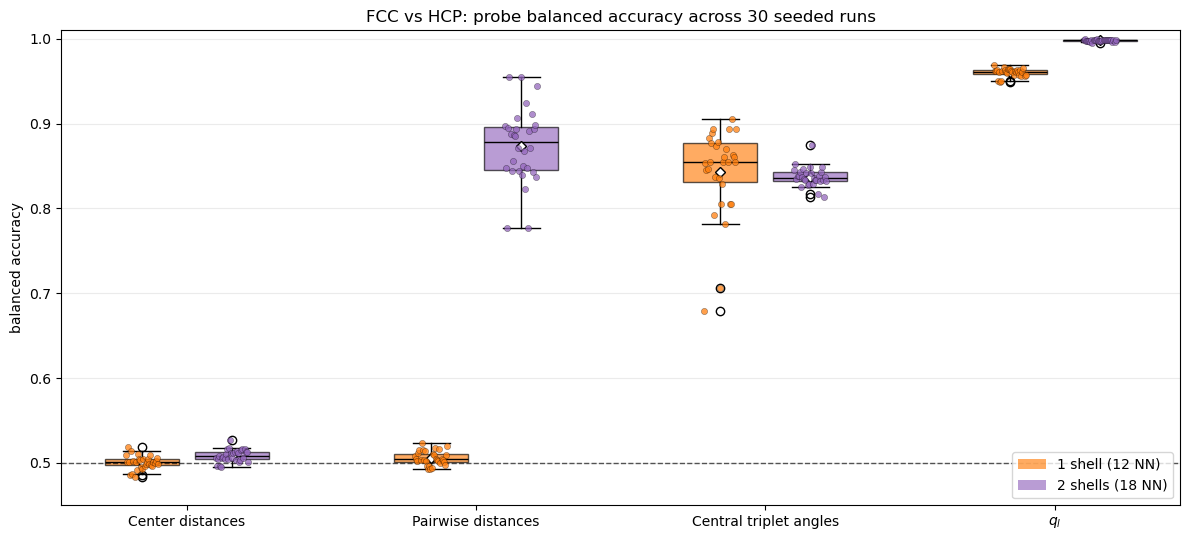

,feature_label,shell_label,mean_balanced_accuracy,std_balanced_accuracy,mean_macro_f1,mean_roc_auc,runs
0,$q_l$,2 shells (18 NN),0.9981,0.0009,0.9981,0.9999,30
1,$q_l$,1 shell (12 NN),0.9605,0.0047,0.9605,0.9768,30
2,Pairwise distances,2 shells (18 NN),0.8740,0.0437,0.8740,0.9259,30
3,Central triplet angles,1 shell (12 NN),0.8428,0.0517,0.8422,0.8846,30
4,Central triplet angles,2 shells (18 NN),0.8374,0.0112,0.8366,0.8557,30
5,Center distances,2 shells (18 NN),0.5084,0.0072,0.5079,0.5106,30
6,Pairwise distances,1 shell (12 NN),0.5058,0.0081,0.5021,0.5109,30
7,Center distances,1 shell (12 NN),0.5005,0.0078,0.5003,0.4989,30


In [20]:
def plot_seed_boxplots(
    scores,
    feature_order,
    feature_labels,
    comparison_title,
    metric="balanced_accuracy",
    chance_level=0.5,
):
    fig, ax = plt.subplots(figsize=(12, 5.5))
    shell_colors = {"first_shell": "tab:orange", "second_shell": "tab:purple"}
    offsets = {"first_shell": -0.28, "second_shell": 0.28}
    centers = np.arange(len(feature_order)) * 1.8

    for shell_name in SHELL_ORDER:
        values = [
            scores.loc[
                (scores["feature"] == feature_kind) & (scores["shell"] == shell_name),
                metric,
            ].to_numpy()
            for feature_kind in feature_order
        ]
        positions = centers + offsets[shell_name]
        boxes = ax.boxplot(
            values,
            positions=positions,
            widths=0.46,
            patch_artist=True,
            showmeans=True,
            meanprops={
                "marker": "D",
                "markerfacecolor": "white",
                "markeredgecolor": "black",
                "markersize": 5,
            },
            medianprops={"color": "black"},
        )
        for box in boxes["boxes"]:
            box.set_facecolor(shell_colors[shell_name])
            box.set_alpha(0.65)
        for position, feature_values in zip(positions, values):
            jitter = np.linspace(-0.10, 0.10, len(feature_values))
            ax.scatter(
                position + jitter,
                feature_values,
                color=shell_colors[shell_name],
                edgecolor="black",
                linewidth=0.25,
                s=20,
                alpha=0.75,
                zorder=3,
            )

    ax.set_xticks(centers)
    ax.set_xticklabels([feature_labels[k] for k in feature_order])
    ax.set_ylabel(metric.replace("_", " "))
    ax.axhline(chance_level, color="black", linestyle="--", linewidth=1, alpha=0.65, label="chance")
    ax.set_ylim(max(0.0, chance_level - 0.05), 1.01)
    ax.set_title(
        f"{comparison_title}: probe {metric.replace('_', ' ')} across "
        f"{scores['seed'].nunique()} seeded runs"
    )
    ax.grid(axis="y", alpha=0.25)
    ax.legend(
        handles=[
            Patch(
                facecolor=shell_colors[shell_name],
                alpha=0.65,
                label=SHELL_CONFIG[shell_name]["label"],
            )
            for shell_name in SHELL_ORDER
        ],
        loc="lower right",
    )
    plt.tight_layout()
    plt.show()


plot_seed_boxplots(
    fcc_hcp_robustness_scores,
    FCC_HCP_FEATURE_ORDER,
    FCC_HCP_FEATURE_LABELS,
    "FCC vs HCP",
)

fcc_hcp_ranking = (
    fcc_hcp_robustness_scores
    .groupby(["feature_label", "shell_label"], as_index=False)
    .agg(
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        std_balanced_accuracy=("balanced_accuracy", "std"),
        mean_macro_f1=("macro_f1", "mean"),
        mean_roc_auc=("roc_auc", "mean"),
        runs=("seed", "nunique"),
    )
    .sort_values("mean_balanced_accuracy", ascending=False)
    .reset_index(drop=True)
)
display(fcc_hcp_ranking.round(4))

### Reading the FCC–HCP result

The key evidence for the simple autoencoder's limit is the **distribution**, not one favorable initialization. Compare each box with the chance level of 0.5 and compare first-shell with second-shell scores feature by feature.

- First-shell FCC and HCP environments should be intrinsically difficult because their nearest-neighbor coordination is the same.
- Second-shell inputs can expose stacking information, but a two-dimensional reconstruction bottleneck is not explicitly encouraged to retain the subtle directions useful for classification.
- Triplet angles provide three-body information with the right geometric invariances. Whether an ordinary dense autoencoder preserves that information is an empirical question answered by its probe distribution.
- $q_l$ is a strong hand-engineered angular prior. Keep the 12-neighbor metadata caveat in mind for the currently stored averaged second-shell values.

## Part III — Liquid vs FCC vs HCP

This repeats the FCC–HCP experiment without changing its feature definitions, architecture, sampling budget, or evaluation protocol; liquid is simply added as a third balanced class. The comparison shows whether an easy-to-separate liquid cluster changes how much of the 2D bottleneck is available for the subtler FCC–HCP distinction.

The primary metrics are macro balanced accuracy, macro-F1, and one-vs-rest macro ROC-AUC. Chance balanced accuracy is $1/3$. The confusion matrices remain important: a good overall score can hide FCC–HCP confusion if liquid is classified almost perfectly.

In [21]:
THREE_PHASES = ("liquid", "fcc", "hcp")
THREE_LABEL_MAP = {"liquid": 0, "fcc": 1, "hcp": 2}
THREE_LABEL_NAMES = {0: "liquid", 1: "fcc", 2: "hcp"}
THREE_LABEL_COLORS = {0: "tab:green", 1: "tab:blue", 2: "tab:orange"}
THREE_FEATURE_ORDER = FCC_HCP_FEATURE_ORDER
THREE_FEATURE_LABELS = FCC_HCP_FEATURE_LABELS

three_phase_shell_data = {
    shell_name: {
        "liquid": shell_data[shell_name]["liquid"],
        "fcc": shell_data[shell_name]["fcc"],
        "hcp": fcc_hcp_shell_data[shell_name]["hcp"],
    }
    for shell_name in SHELL_ORDER
}


def build_three_phase_sampling_plan(
    seed,
    max_samples_per_phase=MAX_SAMPLES_PER_PHASE,
):
    rng = np.random.default_rng(seed)
    reference = three_phase_shell_data["first_shell"]
    n_per_phase = min(
        max_samples_per_phase,
        *(len(reference[phase]["dist"]) for phase in THREE_PHASES),
    )
    plan = {}
    for phase in THREE_PHASES:
        data = reference[phase]
        indices = np.sort(rng.choice(len(data["dist"]), size=n_per_phase, replace=False))
        split = _frame_split(data["frame_indices"][indices], rng)
        plan[phase] = {"indices": indices, "split": split}
    return plan


def prepare_three_phase_experiment(shell_name, feature_kind, plan):
    X_parts, y_parts, split_parts = [], [], []
    for phase in THREE_PHASES:
        entry = plan[phase]
        X_parts.append(
            build_fcc_hcp_feature(
                three_phase_shell_data[shell_name][phase],
                feature_kind,
                entry["indices"],
            )
        )
        y_parts.append(
            np.full(len(entry["indices"]), THREE_LABEL_MAP[phase], dtype=np.int64)
        )
        split_parts.append(entry["split"])
    return (
        np.concatenate(X_parts).astype(np.float32, copy=False),
        np.concatenate(y_parts),
        np.concatenate(split_parts),
    )


def probe_latent_multiclass(Z, y, split, seed):
    fit_mask = split != "test"
    test_mask = split == "test"
    probe = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=5_000,
            class_weight="balanced",
            random_state=seed,
        ),
    )
    probe.fit(Z[fit_mask], y[fit_mask])
    y_test = y[test_mask]
    y_pred = probe.predict(Z[test_mask])
    y_score = probe.predict_proba(Z[test_mask])
    return {
        "probe": probe,
        "y_test": y_test,
        "y_pred": y_pred,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
        "roc_auc": roc_auc_score(
            y_test,
            y_score,
            labels=probe.classes_,
            multi_class="ovr",
            average="macro",
        ),
    }


three_phase_example_plan = build_three_phase_sampling_plan(VISUAL_SEED)
three_phase_plan_rows = []
for phase in THREE_PHASES:
    entry = three_phase_example_plan[phase]
    frames = three_phase_shell_data["first_shell"][phase]["frame_indices"][entry["indices"]]
    for partition in ("train", "val", "test"):
        mask = entry["split"] == partition
        three_phase_plan_rows.append(
            {
                "phase": phase,
                "partition": partition,
                "particles": int(mask.sum()),
                "frames": int(np.unique(frames[mask]).size),
            }
        )
display(pd.DataFrame(three_phase_plan_rows))

,phase,partition,particles,frames
0,liquid,train,7152,181
1,liquid,val,2409,60
2,liquid,test,2439,60
3,fcc,train,7191,361
4,fcc,val,2367,120
5,fcc,test,2442,120
6,hcp,train,7269,361
7,hcp,val,2353,120
8,hcp,test,2378,120


In [22]:
def run_three_phase_suite(seed, keep_artifacts=True, verbose=True):
    plan = build_three_phase_sampling_plan(seed)
    rows = []
    artifacts = {}

    for shell_name in SHELL_ORDER:
        shell_cfg = SHELL_CONFIG[shell_name]
        ql_exact = all(
            three_phase_shell_data[shell_name][phase]["ql_exact"]
            for phase in THREE_PHASES
        )
        for feature_kind in THREE_FEATURE_ORDER:
            if verbose:
                print(
                    f"seed={seed:>3} | {shell_cfg['label']:<18} | "
                    f"{THREE_FEATURE_LABELS[feature_kind]}"
                )
            X, y, split = prepare_three_phase_experiment(shell_name, feature_kind, plan)
            ae = train_autoencoder(X, split, seed)
            probe = probe_latent_multiclass(ae["Z"], y, split, seed)

            rows.append(
                {
                    "seed": seed,
                    "shell": shell_name,
                    "shell_label": shell_cfg["label"],
                    "n_neighbors": shell_cfg["n_neighbors"],
                    "feature": feature_kind,
                    "feature_label": THREE_FEATURE_LABELS[feature_kind],
                    "input_dim": X.shape[1],
                    "n_samples": len(X),
                    "best_epoch": ae["best_epoch"],
                    "validation_mse": ae["best_val_mse"],
                    "accuracy": probe["accuracy"],
                    "balanced_accuracy": probe["balanced_accuracy"],
                    "macro_f1": probe["macro_f1"],
                    "roc_auc": probe["roc_auc"],
                    "q_l_exact_requested_NN": ql_exact if feature_kind == "ql" else pd.NA,
                }
            )
            if keep_artifacts:
                artifacts[(shell_name, feature_kind)] = {
                    "Z": ae["Z"],
                    "y": y,
                    "split": split,
                    "history": ae["history"],
                    "model": ae["model"],
                    "scaler": ae["scaler"],
                    "probe": probe,
                }

            del X, ae
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    return pd.DataFrame(rows), artifacts, plan

### Three-class main run

In [23]:
three_main_scores, three_main_artifacts, three_main_plan = run_three_phase_suite(
    VISUAL_SEED,
    keep_artifacts=True,
    verbose=True,
)

display(
    three_main_scores[score_columns]
    .sort_values(["feature_label", "shell_label"])
    .reset_index(drop=True)
    .round(4)
)

seed= 42 | 1 shell (12 NN)    | Center distances
seed= 42 | 1 shell (12 NN)    | Pairwise distances
seed= 42 | 1 shell (12 NN)    | Central triplet angles
seed= 42 | 1 shell (12 NN)    | $q_l$
seed= 42 | 2 shells (18 NN)   | Center distances
seed= 42 | 2 shells (18 NN)   | Pairwise distances
seed= 42 | 2 shells (18 NN)   | Central triplet angles
seed= 42 | 2 shells (18 NN)   | $q_l$


,shell_label,feature_label,input_dim,best_epoch,validation_mse,accuracy,balanced_accuracy,macro_f1,roc_auc,q_l_exact_requested_NN
0,1 shell (12 NN),$q_l$,20,25,0.0073,0.9074,0.9073,0.9075,0.9736,True
1,2 shells (18 NN),$q_l$,20,25,0.0064,0.9893,0.9892,0.9892,0.9994,False
2,1 shell (12 NN),Center distances,12,25,0.0044,0.5943,0.5926,0.5854,0.8020,<NA>
3,2 shells (18 NN),Center distances,18,25,0.0072,0.6252,0.6243,0.6212,0.8223,<NA>
4,1 shell (12 NN),Central triplet angles,66,25,0.0016,0.7945,0.7940,0.7940,0.8772,<NA>
5,2 shells (18 NN),Central triplet angles,153,24,0.0011,0.7361,0.7352,0.7339,0.8359,<NA>
6,1 shell (12 NN),Pairwise distances,78,23,0.0015,0.6549,0.6532,0.6502,0.8355,<NA>
7,2 shells (18 NN),Pairwise distances,171,24,0.0013,0.9103,0.9104,0.9108,0.9723,<NA>


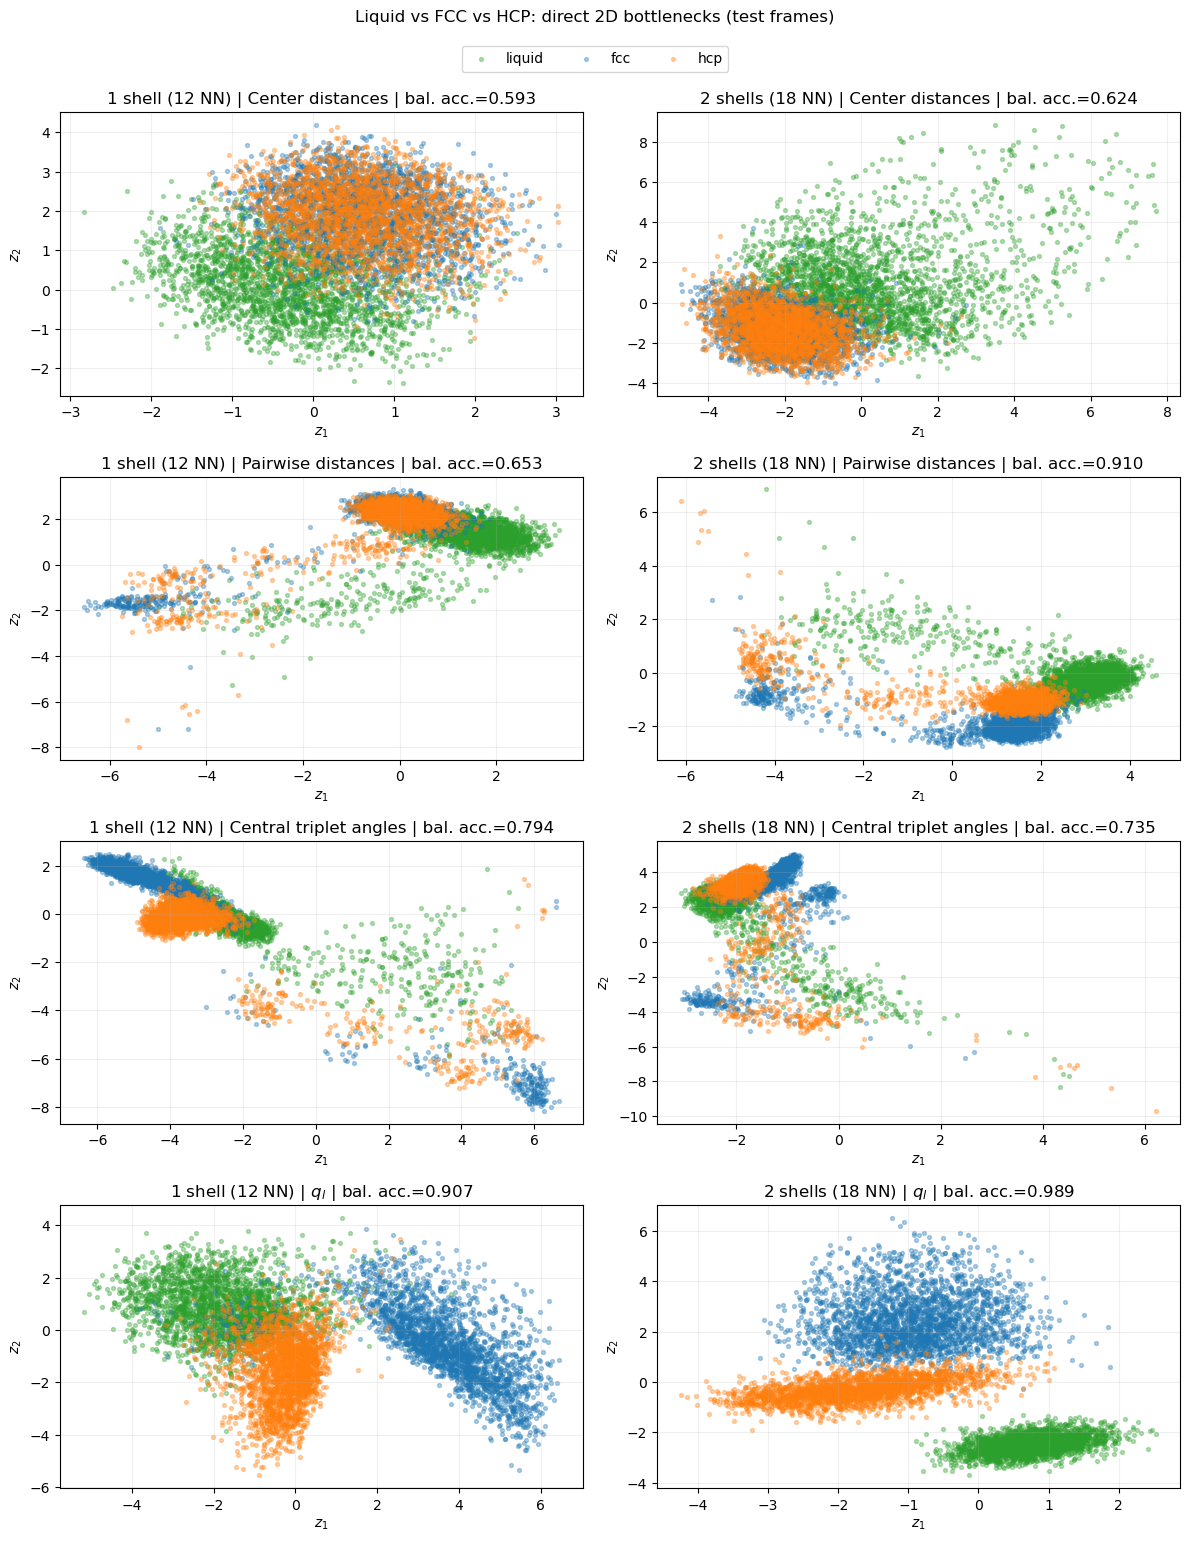

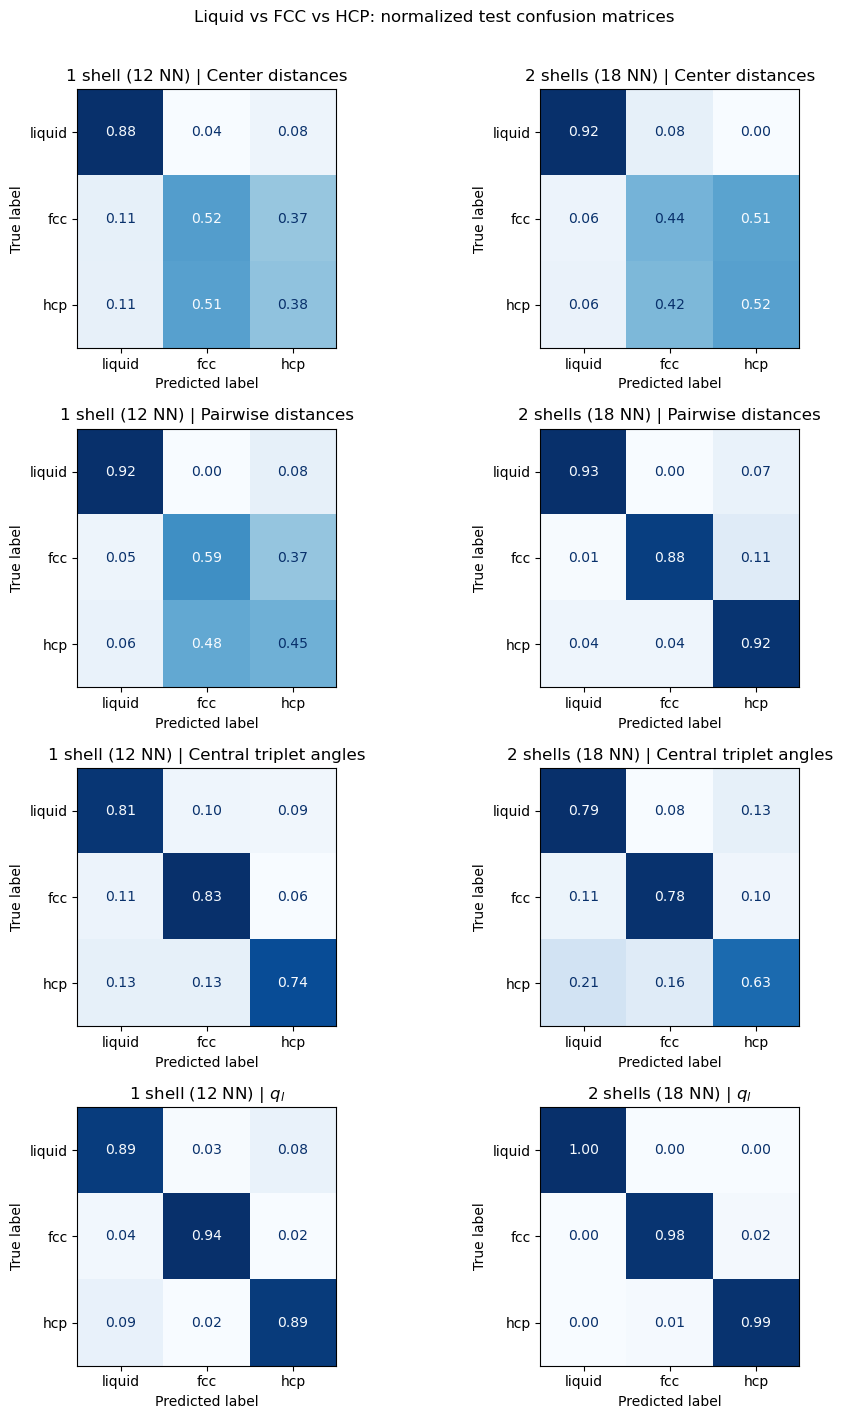

balanced_accuracy                         macro_f1  \
shell_label              1 shell (12 NN) 2 shells (18 NN) 1 shell (12 NN)   
feature_label                                                               
$q_l$                             0.9073           0.9892          0.9075   
Center distances                  0.5926           0.6243          0.5854   
Central triplet angles            0.7940           0.7352          0.7940   
Pairwise distances                0.6532           0.9104          0.6502   

                                                roc_auc                   
shell_label            2 shells (18 NN) 1 shell (12 NN) 2 shells (18 NN)  
feature_label                                                             
$q_l$                            0.9892          0.9736           0.9994  
Center distances                 0.6212          0.8020           0.8223  
Central triplet angles           0.7339          0.8772           0.8359  
Pairwise distances               0.9108          0.8355           0.9723

In [24]:
def plot_multiclass_latent_grid(
    artifacts,
    feature_order,
    feature_labels,
    comparison_title,
    split_to_plot="test",
):
    fig, axes = plt.subplots(
        len(feature_order),
        len(SHELL_ORDER),
        figsize=(12, 15),
        squeeze=False,
    )
    rng = np.random.default_rng(VISUAL_SEED)

    for row, feature_kind in enumerate(feature_order):
        for col, shell_name in enumerate(SHELL_ORDER):
            ax = axes[row, col]
            artifact = artifacts[(shell_name, feature_kind)]
            Z, y, split = artifact["Z"], artifact["y"], artifact["split"]
            keep = split == split_to_plot
            for phase in THREE_PHASES:
                label = THREE_LABEL_MAP[phase]
                indices = np.flatnonzero(keep & (y == label))
                if len(indices) > MAX_PLOT_POINTS_PER_PHASE:
                    indices = rng.choice(indices, MAX_PLOT_POINTS_PER_PHASE, replace=False)
                ax.scatter(
                    Z[indices, 0],
                    Z[indices, 1],
                    s=8,
                    alpha=0.35,
                    color=THREE_LABEL_COLORS[label],
                    label=phase,
                    rasterized=True,
                )
            score = artifact["probe"]["balanced_accuracy"]
            ax.set_title(
                f"{SHELL_CONFIG[shell_name]['label']} | "
                f"{feature_labels[feature_kind]} | bal. acc.={score:.3f}"
            )
            ax.set_xlabel(r"$z_1$")
            ax.set_ylabel(r"$z_2$")
            ax.grid(alpha=0.2)

    handles, legend_labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        legend_labels,
        loc="upper center",
        ncol=3,
        bbox_to_anchor=(0.5, 1.005),
    )
    fig.suptitle(
        f"{comparison_title}: direct 2D bottlenecks ({split_to_plot} frames)",
        y=1.025,
    )
    plt.tight_layout()
    plt.show()


def plot_multiclass_confusion_grid(
    artifacts,
    feature_order,
    feature_labels,
    comparison_title,
):
    fig, axes = plt.subplots(
        len(feature_order),
        len(SHELL_ORDER),
        figsize=(10, 14),
        squeeze=False,
    )
    labels = [THREE_LABEL_MAP[phase] for phase in THREE_PHASES]
    names = [THREE_LABEL_NAMES[label] for label in labels]
    for row, feature_kind in enumerate(feature_order):
        for col, shell_name in enumerate(SHELL_ORDER):
            ax = axes[row, col]
            probe = artifacts[(shell_name, feature_kind)]["probe"]
            matrix = confusion_matrix(
                probe["y_test"],
                probe["y_pred"],
                labels=labels,
                normalize="true",
            )
            ConfusionMatrixDisplay(matrix, display_labels=names).plot(
                ax=ax,
                cmap="Blues",
                colorbar=False,
                values_format=".2f",
            )
            ax.set_title(
                f"{SHELL_CONFIG[shell_name]['label']} | {feature_labels[feature_kind]}"
            )
            ax.grid(False)
    fig.suptitle(f"{comparison_title}: normalized test confusion matrices", y=1.01)
    plt.tight_layout()
    plt.show()


plot_multiclass_latent_grid(
    three_main_artifacts,
    THREE_FEATURE_ORDER,
    THREE_FEATURE_LABELS,
    "Liquid vs FCC vs HCP",
)
plot_multiclass_confusion_grid(
    three_main_artifacts,
    THREE_FEATURE_ORDER,
    THREE_FEATURE_LABELS,
    "Liquid vs FCC vs HCP",
)

three_metric_table = three_main_scores.pivot(
    index="feature_label",
    columns="shell_label",
    values=["balanced_accuracy", "macro_f1", "roc_auc"],
)
display(three_metric_table.round(4))

### Three-class robustness across 30 random seeds

This is the same full seeded pipeline used in both binary sections. The dashed reference in the boxplot is the three-class chance level, $1/3$.

Three-class robustness run for seed 0
Three-class robustness run for seed 1
Three-class robustness run for seed 2
Three-class robustness run for seed 3
Three-class robustness run for seed 4
Three-class robustness run for seed 5
Three-class robustness run for seed 6
Three-class robustness run for seed 7
Three-class robustness run for seed 8
Three-class robustness run for seed 9
Three-class robustness run for seed 10
Three-class robustness run for seed 11
Three-class robustness run for seed 12
Three-class robustness run for seed 13
Three-class robustness run for seed 14
Three-class robustness run for seed 15
Three-class robustness run for seed 16
Three-class robustness run for seed 17
Three-class robustness run for seed 18
Three-class robustness run for seed 19
Three-class robustness run for seed 20
Three-class robustness run for seed 21
Three-class robustness run for seed 22
Three-class robustness run for seed 23
Three-class robustness run for seed 24
Three-class robustness run for seed

accuracy                          \
                                            mean     std     min     max   
feature_label          shell_label                                         
Center distances       1 shell (12 NN)    0.5889  0.0049  0.5794  0.5986   
Pairwise distances     1 shell (12 NN)    0.6316  0.0233  0.5482  0.6558   
Central triplet angles 1 shell (12 NN)    0.6803  0.0550  0.5969  0.7945   
$q_l$                  1 shell (12 NN)    0.9035  0.0053  0.8911  0.9134   
Center distances       2 shells (18 NN)   0.6280  0.0067  0.6128  0.6418   
Pairwise distances     2 shells (18 NN)   0.8984  0.0179  0.8486  0.9239   
Central triplet angles 2 shells (18 NN)   0.7250  0.0182  0.6905  0.7933   
$q_l$                  2 shells (18 NN)   0.9891  0.0087  0.9579  0.9978   

                                        balanced_accuracy                  \
                                                     mean     std     min   
feature_label          shell_label                                          
Center distances       1 shell (12 NN)             0.5892  0.0045  0.5790   
Pairwise distances     1 shell (12 NN)             0.6318  0.0237  0.5456   
Central triplet angles 1 shell (12 NN)             0.6801  0.0554  0.5964   
$q_l$                  1 shell (12 NN)             0.9035  0.0053  0.8910   
Center distances       2 shells (18 NN)            0.6282  0.0060  0.6132   
Pairwise distances     2 shells (18 NN)            0.8985  0.0177  0.8483   
Central triplet angles 2 shells (18 NN)            0.7251  0.0180  0.6917   
$q_l$                  2 shells (18 NN)            0.9891  0.0086  0.9581   

                                                macro_f1                  \
                                            max     mean     std     min   
feature_label          shell_label                                         
Center distances       1 shell (12 NN)   0.5979   0.5819  0.0047  0.5726   
Pairwise distances     1 shell (12 NN)   0.6548   0.6270  0.0277  0.5165   
Central triplet angles 1 shell (12 NN)   0.7945   0.6661  0.0664  0.5518   
$q_l$                  1 shell (12 NN)   0.9134   0.9038  0.0053  0.8914   
Center distances       2 shells (18 NN)  0.6403   0.6236  0.0065  0.6089   
Pairwise distances     2 shells (18 NN)  0.9237   0.8993  0.0178  0.8490   
Central triplet angles 2 shells (18 NN)  0.7930   0.7241  0.0191  0.6868   
$q_l$                  2 shells (18 NN)  0.9978   0.9891  0.0086  0.9581   

                                                roc_auc                  \
                                            max    mean     std     min   
feature_label          shell_label                                        
Center distances       1 shell (12 NN)   0.5905  0.8018  0.0027  0.7976   
Pairwise distances     1 shell (12 NN)   0.6516  0.8202  0.0212  0.7391   
Central triplet angles 1 shell (12 NN)   0.7955  0.8191  0.0365  0.7589   
$q_l$                  1 shell (12 NN)   0.9137  0.9742  0.0026  0.9688   
Center distances       2 shells (18 NN)  0.6352  0.8216  0.0024  0.8159   
Pairwise distances     2 shells (18 NN)  0.9245  0.9705  0.0072  0.9484   
Central triplet angles 2 shells (18 NN)  0.7944  0.8403  0.0187  0.8118   
$q_l$                  2 shells (18 NN)  0.9978  0.9993  0.0011  0.9946   

                                                 
                                            max  
feature_label          shell_label               
Center distances       1 shell (12 NN)   0.8071  
Pairwise distances     1 shell (12 NN)   0.8364  
Central triplet angles 1 shell (12 NN)   0.9137  
$q_l$                  1 shell (12 NN)   0.9785  
Center distances       2 shells (18 NN)  0.8263  
Pairwise distances     2 shells (18 NN)  0.9790  
Central triplet angles 2 shells (18 NN)  0.9173  
$q_l$                  2 shells (18 NN)  1.0000

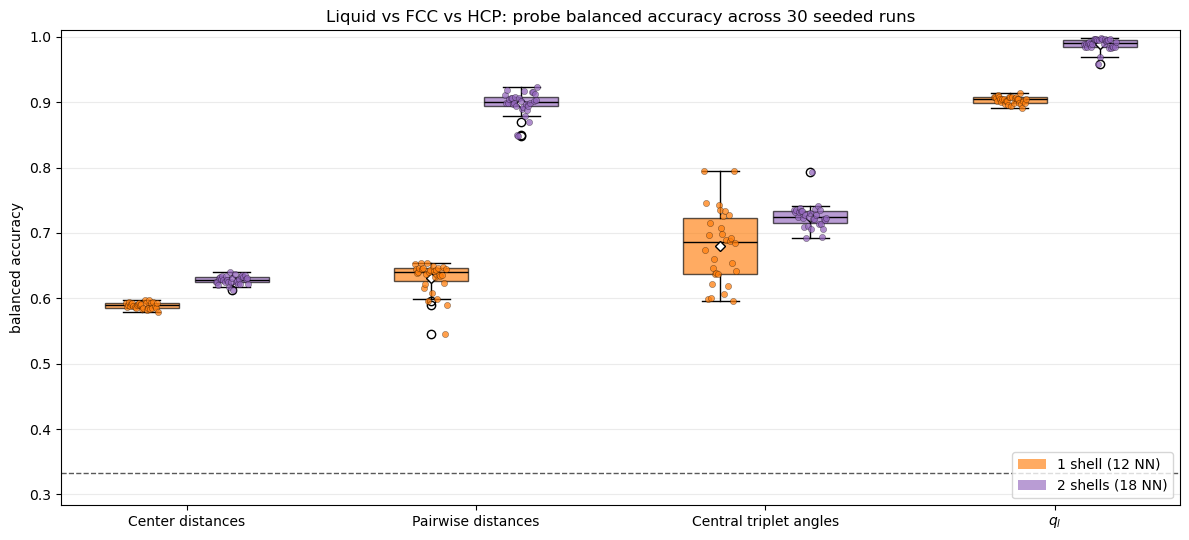

,feature_label,shell_label,mean_balanced_accuracy,std_balanced_accuracy,mean_macro_f1,mean_roc_auc,runs
0,$q_l$,2 shells (18 NN),0.9891,0.0086,0.9891,0.9993,30
1,$q_l$,1 shell (12 NN),0.9035,0.0053,0.9038,0.9742,30
2,Pairwise distances,2 shells (18 NN),0.8985,0.0177,0.8993,0.9705,30
3,Central triplet angles,2 shells (18 NN),0.7251,0.0180,0.7241,0.8403,30
4,Central triplet angles,1 shell (12 NN),0.6801,0.0554,0.6661,0.8191,30
5,Pairwise distances,1 shell (12 NN),0.6318,0.0237,0.6270,0.8202,30
6,Center distances,2 shells (18 NN),0.6282,0.0060,0.6236,0.8216,30
7,Center distances,1 shell (12 NN),0.5892,0.0045,0.5819,0.8018,30


In [25]:
three_score_frames = [three_main_scores]
for seed in ROBUSTNESS_SEEDS:
    if seed == VISUAL_SEED:
        continue
    print(f"Three-class robustness run for seed {seed}")
    seeded_scores, _, _ = run_three_phase_suite(
        seed,
        keep_artifacts=False,
        verbose=False,
    )
    three_score_frames.append(seeded_scores)

three_robustness_scores = pd.concat(three_score_frames, ignore_index=True)
three_robustness_summary = (
    three_robustness_scores
    .groupby(["feature_label", "shell_label"], sort=False)[list(metric_names)]
    .agg(["mean", "std", "min", "max"])
)
display(three_robustness_summary.round(4))

plot_seed_boxplots(
    three_robustness_scores,
    THREE_FEATURE_ORDER,
    THREE_FEATURE_LABELS,
    "Liquid vs FCC vs HCP",
    chance_level=1 / 3,
)

three_ranking = (
    three_robustness_scores
    .groupby(["feature_label", "shell_label"], as_index=False)
    .agg(
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        std_balanced_accuracy=("balanced_accuracy", "std"),
        mean_macro_f1=("macro_f1", "mean"),
        mean_roc_auc=("roc_auc", "mean"),
        runs=("seed", "nunique"),
    )
    .sort_values("mean_balanced_accuracy", ascending=False)
    .reset_index(drop=True)
)
display(three_ranking.round(4))

In [26]:
comparison_summary = pd.concat(
    [
        robustness_scores.assign(comparison="liquid vs fcc"),
        fcc_hcp_robustness_scores.assign(comparison="fcc vs hcp"),
        three_robustness_scores.assign(comparison="liquid vs fcc vs hcp"),
    ],
    ignore_index=True,
)

comparison_table = (
    comparison_summary
    .groupby(["comparison", "feature_label", "shell_label"])["balanced_accuracy"]
    .agg(["mean", "std"])
)
display(comparison_table.round(4))

mean     std
comparison           feature_label          shell_label                     
fcc vs hcp           $q_l$                  1 shell (12 NN)   0.9605  0.0047
                                            2 shells (18 NN)  0.9981  0.0009
                     Center distances       1 shell (12 NN)   0.5005  0.0078
                                            2 shells (18 NN)  0.5084  0.0072
                     Central triplet angles 1 shell (12 NN)   0.8428  0.0517
                                            2 shells (18 NN)  0.8374  0.0112
                     Pairwise distances     1 shell (12 NN)   0.5058  0.0081
                                            2 shells (18 NN)  0.8740  0.0437
liquid vs fcc        $q_l$                  1 shell (12 NN)   0.9464  0.0049
                                            2 shells (18 NN)  0.9999  0.0001
                     Center distances       1 shell (12 NN)   0.8853  0.0046
                                            2 shells (18 NN)  0.9242  0.0039
                     Neighbor vectors       1 shell (12 NN)   0.5036  0.0079
                                            2 shells (18 NN)  0.5050  0.0096
                     Pairwise distances     1 shell (12 NN)   0.9155  0.0370
                                            2 shells (18 NN)  0.9816  0.0019
liquid vs fcc vs hcp $q_l$                  1 shell (12 NN)   0.9035  0.0053
                                            2 shells (18 NN)  0.9891  0.0086
                     Center distances       1 shell (12 NN)   0.5892  0.0045
                                            2 shells (18 NN)  0.6282  0.0060
                     Central triplet angles 1 shell (12 NN)   0.6801  0.0554
                                            2 shells (18 NN)  0.7251  0.0180
                     Pairwise distances     1 shell (12 NN)   0.6318  0.0237
                                            2 shells (18 NN)  0.8985  0.0177

## Part IV — EGNN with a two-dimensional graph bottleneck

The input is always the complete local neighborhood graph: one center node plus 12 or 18 neighbor nodes. Directed edges connect every pair of distinct nodes. Edge messages depend on scalar node features and squared interparticle distance; coordinate updates are parallel to relative displacement vectors. This gives E(3)-equivariant message passing. Mean/max pooling of scalar node states is permutation invariant, after which a dense network maps the graph embedding to the **two-dimensional latent**.

Four separate graph autoencoders share this encoder design but use target-specific MLP decoders:

1. sorted distances from the center;
2. sorted pairwise distances among center + neighbors;
3. sorted central triplet angles;
4. $q_l$, using standard/non-averaged values for one shell and Lechner–Dellago averaged values for two shells.

All targets are invariant, so an ordinary MLP decoder is symmetry compatible. The phase labels remain probe-only. This first EGNN chapter runs the three-class visual benchmark once; the 30-seed EGNN robustness sweep is deliberately optional because it is much more expensive than the dense-AE sweeps.

In [27]:
# EGNN configuration
RUN_EGNN = True
RUN_EGNN_ROBUSTNESS = False
EGNN_MAX_SAMPLES_PER_PHASE = 3_000
EGNN_EPOCHS = 20
EGNN_BATCH_SIZE = 256
EGNN_LEARNING_RATE = 1e-3
EGNN_WEIGHT_DECAY = 1e-4
EGNN_EARLY_STOPPING_PATIENCE = 5
EGNN_FEATURE_DIM = 48
EGNN_MESSAGE_DIM = 48
EGNN_N_LAYERS = 4
EGNN_COORD_UPDATE_SCALE = 0.05
EGNN_GRAD_CLIP = 5.0
EGNN_LATENT_DIM = 2
EGNN_TARGET_ORDER = THREE_FEATURE_ORDER
EGNN_TARGET_LABELS = THREE_FEATURE_LABELS

if os.environ.get("AE_SMOKE_TEST") == "1":
    EGNN_MAX_SAMPLES_PER_PHASE = 256
    EGNN_EPOCHS = 2
    EGNN_EARLY_STOPPING_PATIENCE = 2

print("EGNN enabled:", RUN_EGNN)
print("EGNN latent dimension:", EGNN_LATENT_DIM)
print("EGNN samples per phase:", EGNN_MAX_SAMPLES_PER_PHASE)

EGNN enabled: True
EGNN latent dimension: 2
EGNN samples per phase: 3000


In [28]:
class EGNNMLP(nn.Module):
    def __init__(self, dimensions, activation=nn.SiLU, final_activation=False):
        super().__init__()
        layers = []
        for index in range(len(dimensions) - 1):
            layers.append(nn.Linear(dimensions[index], dimensions[index + 1]))
            if index < len(dimensions) - 2 or final_activation:
                layers.append(activation())
        self.network = nn.Sequential(*layers)

    def forward(self, inputs):
        return self.network(inputs)


class EGNNLayer(nn.Module):
    """E(n)-equivariant message and coordinate update for a fixed batched graph."""
    def __init__(
        self,
        feature_dim=EGNN_FEATURE_DIM,
        message_dim=EGNN_MESSAGE_DIM,
        coordinate_scale=EGNN_COORD_UPDATE_SCALE,
    ):
        super().__init__()
        self.edge_mlp = EGNNMLP(
            [2 * feature_dim + 1, message_dim, message_dim, message_dim]
        )
        self.coordinate_mlp = EGNNMLP([message_dim, message_dim, 1])
        self.node_mlp = EGNNMLP(
            [feature_dim + message_dim, message_dim, feature_dim]
        )
        self.norm = nn.LayerNorm(feature_dim)
        self.coordinate_scale = coordinate_scale

    def forward(self, node_features, coordinates, edge_index):
        receivers, senders = edge_index
        receiver_features = node_features[:, receivers, :]
        sender_features = node_features[:, senders, :]
        relative = coordinates[:, receivers, :] - coordinates[:, senders, :]
        squared_distance = relative.square().sum(dim=-1, keepdim=True)

        messages = self.edge_mlp(
            torch.cat(
                [receiver_features, sender_features, squared_distance],
                dim=-1,
            )
        )
        coordinate_weight = torch.tanh(self.coordinate_mlp(messages))

        node_count = coordinates.shape[1]
        degrees = torch.bincount(receivers, minlength=node_count).clamp_min(1)
        degree_scale = degrees.to(coordinates.dtype).view(1, node_count, 1)

        coordinate_updates = torch.zeros_like(coordinates)
        coordinate_updates.index_add_(1, receivers, relative * coordinate_weight)
        coordinates = (
            coordinates
            + self.coordinate_scale * coordinate_updates / degree_scale
        )

        aggregated = torch.zeros(
            node_features.shape[0],
            node_count,
            messages.shape[-1],
            device=node_features.device,
            dtype=node_features.dtype,
        )
        aggregated.index_add_(1, receivers, messages)
        aggregated = aggregated / degree_scale
        update = self.node_mlp(torch.cat([node_features, aggregated], dim=-1))
        node_features = self.norm(node_features + update)
        return node_features, coordinates


class EGNNGraphEncoder(nn.Module):
    def __init__(
        self,
        feature_dim=EGNN_FEATURE_DIM,
        n_layers=EGNN_N_LAYERS,
        latent_dim=EGNN_LATENT_DIM,
    ):
        super().__init__()
        # Invariant node inputs: central-node marker and radius from the center.
        self.node_embedding = EGNNMLP([2, feature_dim, feature_dim])
        self.layers = nn.ModuleList(
            [EGNNLayer(feature_dim=feature_dim) for _ in range(n_layers)]
        )
        # This dense graph-level head is the requested squeeze to two dimensions.
        self.to_latent = EGNNMLP(
            [2 * feature_dim, feature_dim, feature_dim, latent_dim]
        )

    def forward(self, coordinates, edge_index):
        relative_to_center = coordinates - coordinates[:, :1, :]
        radii = torch.linalg.norm(relative_to_center, dim=-1, keepdim=True)
        center_marker = torch.zeros_like(radii)
        center_marker[:, 0, 0] = 1.0
        node_features = self.node_embedding(
            torch.cat([center_marker, radii], dim=-1)
        )

        updated_coordinates = coordinates
        for layer in self.layers:
            node_features, updated_coordinates = layer(
                node_features,
                updated_coordinates,
                edge_index,
            )

        pooled = torch.cat(
            [
                node_features.mean(dim=1),
                node_features.max(dim=1).values,
            ],
            dim=-1,
        )
        return self.to_latent(pooled)


class EGNNTargetDecoder(nn.Module):
    def __init__(self, output_dim, hidden_dim=EGNN_FEATURE_DIM):
        super().__init__()
        self.network = nn.Sequential(
            EGNNMLP(
                [EGNN_LATENT_DIM, hidden_dim, hidden_dim, hidden_dim, output_dim]
            ),
            nn.Sigmoid(),
        )

    def forward(self, latent):
        return self.network(latent)


class EGNNReconstructionAutoencoder(nn.Module):
    def __init__(self, output_dim):
        super().__init__()
        self.encoder = EGNNGraphEncoder()
        self.decoder = EGNNTargetDecoder(output_dim)

    def encode(self, coordinates, edge_index):
        return self.encoder(coordinates, edge_index)

    def forward(self, coordinates, edge_index):
        latent = self.encode(coordinates, edge_index)
        return self.decoder(latent), latent


def fully_connected_edge_index(n_nodes):
    receivers, senders = [], []
    for receiver in range(n_nodes):
        for sender in range(n_nodes):
            if receiver != sender:
                receivers.append(receiver)
                senders.append(sender)
    return torch.tensor([receivers, senders], dtype=torch.long)

In [29]:
def coordinates_with_center(vectors):
    center = np.zeros((len(vectors), 1, 3), dtype=np.float32)
    return np.concatenate([center, vectors.astype(np.float32)], axis=1)


def egnn_target_array(data, target_kind, indices):
    if target_kind == "radii":
        return data["dist"][indices].copy()
    if target_kind == "pairwise_distances":
        return pairwise_distance_features(data["vec_dist"][indices])
    if target_kind == "triplets":
        return triplet_angle_features(data["vec_dist"][indices])
    if target_kind == "ql":
        return data["ql"][indices].copy()
    raise KeyError(target_kind)


def prepare_egnn_experiment(shell_name, target_kind, plan):
    coordinate_parts, target_parts, label_parts, split_parts = [], [], [], []
    for phase in THREE_PHASES:
        entry = plan[phase]
        data = three_phase_shell_data[shell_name][phase]
        coordinate_parts.append(
            coordinates_with_center(data["vec_dist"][entry["indices"]])
        )
        target_parts.append(
            egnn_target_array(data, target_kind, entry["indices"])
        )
        label_parts.append(
            np.full(len(entry["indices"]), THREE_LABEL_MAP[phase], dtype=np.int64)
        )
        split_parts.append(entry["split"])

    return (
        np.concatenate(coordinate_parts).astype(np.float32, copy=False),
        np.concatenate(target_parts).astype(np.float32, copy=False),
        np.concatenate(label_parts),
        np.concatenate(split_parts),
    )


def train_egnn_reconstructor(coordinates, targets, split, seed):
    set_seed(seed)
    train_mask = split == "train"
    val_mask = split == "val"
    test_mask = split == "test"

    # Coordinates are relative to the center. Fit one physical scale on train only.
    training_radii = np.linalg.norm(coordinates[train_mask, 1:, :], axis=-1)
    coordinate_scale = float(np.median(training_radii))
    if not np.isfinite(coordinate_scale) or coordinate_scale <= 0:
        coordinate_scale = 1.0
    scaled_coordinates = (coordinates / coordinate_scale).astype(np.float32)

    target_scaler = MinMaxScaler()
    target_scaler.fit(targets[train_mask])
    scaled_targets = target_scaler.transform(targets).astype(np.float32)

    train_coordinates = torch.from_numpy(scaled_coordinates[train_mask])
    train_targets = torch.from_numpy(scaled_targets[train_mask])
    val_coordinates = torch.from_numpy(scaled_coordinates[val_mask])
    val_targets = torch.from_numpy(scaled_targets[val_mask])
    generator = torch.Generator().manual_seed(seed)

    train_loader = DataLoader(
        TensorDataset(train_coordinates, train_targets),
        batch_size=EGNN_BATCH_SIZE,
        shuffle=True,
        generator=generator,
        num_workers=0,
    )
    val_loader = DataLoader(
        TensorDataset(val_coordinates, val_targets),
        batch_size=EGNN_BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    )

    edge_index = fully_connected_edge_index(scaled_coordinates.shape[1]).to(DEVICE)
    model = EGNNReconstructionAutoencoder(scaled_targets.shape[1]).to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=EGNN_LEARNING_RATE,
        weight_decay=EGNN_WEIGHT_DECAY,
    )
    criterion = nn.MSELoss()
    history = {"train_mse": [], "val_mse": []}
    best_state = None
    best_val = np.inf
    best_epoch = -1
    stale_epochs = 0

    for epoch in range(EGNN_EPOCHS):
        model.train()
        running = 0.0
        for coordinate_batch, target_batch in train_loader:
            coordinate_batch = coordinate_batch.to(DEVICE)
            target_batch = target_batch.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            prediction, _ = model(coordinate_batch, edge_index)
            loss = criterion(prediction, target_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), EGNN_GRAD_CLIP)
            optimizer.step()
            running += loss.item() * len(coordinate_batch)
        train_mse = running / len(train_coordinates)

        model.eval()
        running = 0.0
        with torch.no_grad():
            for coordinate_batch, target_batch in val_loader:
                coordinate_batch = coordinate_batch.to(DEVICE)
                target_batch = target_batch.to(DEVICE)
                prediction, _ = model(coordinate_batch, edge_index)
                running += criterion(prediction, target_batch).item() * len(coordinate_batch)
        val_mse = running / len(val_coordinates)
        history["train_mse"].append(train_mse)
        history["val_mse"].append(val_mse)

        if val_mse < best_val - 1e-8:
            best_val = val_mse
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= EGNN_EARLY_STOPPING_PATIENCE:
                break

    model.load_state_dict(best_state)
    model.eval()
    latent_chunks = []
    test_squared_error = 0.0
    test_count = 0
    with torch.no_grad():
        for start in range(0, len(scaled_coordinates), EGNN_BATCH_SIZE):
            stop = min(start + EGNN_BATCH_SIZE, len(scaled_coordinates))
            coordinate_batch = torch.from_numpy(
                scaled_coordinates[start:stop]
            ).to(DEVICE)
            prediction, latent = model(coordinate_batch, edge_index)
            latent_chunks.append(latent.cpu().numpy())
            local_test = test_mask[start:stop]
            if np.any(local_test):
                target_batch = torch.from_numpy(
                    scaled_targets[start:stop][local_test]
                ).to(DEVICE)
                test_squared_error += nn.functional.mse_loss(
                    prediction[local_test],
                    target_batch,
                    reduction="sum",
                ).item()
                test_count += int(local_test.sum()) * scaled_targets.shape[1]

    return {
        "model": model,
        "target_scaler": target_scaler,
        "coordinate_scale": coordinate_scale,
        "edge_index": edge_index,
        "history": history,
        "Z": np.concatenate(latent_chunks),
        "best_epoch": best_epoch + 1,
        "best_val_mse": float(best_val),
        "test_mse": test_squared_error / test_count,
    }

In [30]:
def run_egnn_suite(seed=VISUAL_SEED, keep_artifacts=True, verbose=True):
    plan = build_three_phase_sampling_plan(
        seed,
        max_samples_per_phase=EGNN_MAX_SAMPLES_PER_PHASE,
    )
    rows = []
    artifacts = {}

    for shell_name in SHELL_ORDER:
        shell_cfg = SHELL_CONFIG[shell_name]
        ql_exact = all(
            three_phase_shell_data[shell_name][phase]["ql_exact"]
            for phase in THREE_PHASES
        )
        for target_kind in EGNN_TARGET_ORDER:
            if verbose:
                print(
                    f"EGNN seed={seed:>3} | {shell_cfg['label']:<18} | "
                    f"decode {EGNN_TARGET_LABELS[target_kind]}"
                )
            coordinates, targets, y, split = prepare_egnn_experiment(
                shell_name,
                target_kind,
                plan,
            )
            trained = train_egnn_reconstructor(coordinates, targets, split, seed)
            probe = probe_latent_multiclass(trained["Z"], y, split, seed)

            rows.append(
                {
                    "seed": seed,
                    "shell": shell_name,
                    "shell_label": shell_cfg["label"],
                    "n_neighbors": shell_cfg["n_neighbors"],
                    "n_graph_nodes": coordinates.shape[1],
                    "target": target_kind,
                    "target_label": EGNN_TARGET_LABELS[target_kind],
                    "target_dim": targets.shape[1],
                    "latent_dim": trained["Z"].shape[1],
                    "n_samples": len(y),
                    "best_epoch": trained["best_epoch"],
                    "validation_mse": trained["best_val_mse"],
                    "test_reconstruction_mse": trained["test_mse"],
                    "accuracy": probe["accuracy"],
                    "balanced_accuracy": probe["balanced_accuracy"],
                    "macro_f1": probe["macro_f1"],
                    "roc_auc": probe["roc_auc"],
                    "q_l_variant": shell_cfg["ql_variant"] if target_kind == "ql" else pd.NA,
                    "q_l_exact_requested_NN": ql_exact if target_kind == "ql" else pd.NA,
                }
            )
            if keep_artifacts:
                artifacts[(shell_name, target_kind)] = {
                    "Z": trained["Z"],
                    "y": y,
                    "split": split,
                    "history": trained["history"],
                    "model": trained["model"],
                    "target_scaler": trained["target_scaler"],
                    "coordinate_scale": trained["coordinate_scale"],
                    "edge_index": trained["edge_index"],
                    "probe": probe,
                }

            del coordinates, targets, trained
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    return pd.DataFrame(rows), artifacts, plan

### EGNN main run and latent probes

In [31]:
if RUN_EGNN:
    egnn_scores, egnn_artifacts, egnn_plan = run_egnn_suite(
        VISUAL_SEED,
        keep_artifacts=True,
        verbose=True,
    )
    display(
        egnn_scores.sort_values(["target_label", "shell_label"])
        .reset_index(drop=True)
        .round(4)
    )

EGNN seed= 42 | 1 shell (12 NN)    | decode Center distances
EGNN seed= 42 | 1 shell (12 NN)    | decode Pairwise distances
EGNN seed= 42 | 1 shell (12 NN)    | decode Central triplet angles
EGNN seed= 42 | 1 shell (12 NN)    | decode $q_l$
EGNN seed= 42 | 2 shells (18 NN)   | decode Center distances
EGNN seed= 42 | 2 shells (18 NN)   | decode Pairwise distances
EGNN seed= 42 | 2 shells (18 NN)   | decode Central triplet angles
EGNN seed= 42 | 2 shells (18 NN)   | decode $q_l$


,seed,shell,shell_label,n_neighbors,n_graph_nodes,target,target_label,target_dim,latent_dim,n_samples,best_epoch,validation_mse,test_reconstruction_mse,accuracy,balanced_accuracy,macro_f1,roc_auc,q_l_variant,q_l_exact_requested_NN
0,42,first_shell,1 shell (12 NN),12,13,ql,$q_l$,20,2,9000,20,0.0165,0.0176,0.5816,0.5856,0.5469,0.7998,standard,True
1,42,second_shell,2 shells (18 NN),18,19,ql,$q_l$,20,2,9000,20,0.0181,0.0183,0.6114,0.6136,0.6060,0.8114,Lechner-Dellago averaged,False
2,42,first_shell,1 shell (12 NN),12,13,radii,Center distances,12,2,9000,20,0.0057,0.0058,0.5704,0.5721,0.5671,0.7952,<NA>,<NA>
3,42,second_shell,2 shells (18 NN),18,19,radii,Center distances,18,2,9000,17,0.0128,0.0133,0.5917,0.5930,0.5902,0.8045,<NA>,<NA>
4,42,first_shell,1 shell (12 NN),12,13,triplets,Central triplet angles,66,2,9000,20,0.0046,0.0046,0.5789,0.5808,0.5720,0.7880,<NA>,<NA>
5,42,second_shell,2 shells (18 NN),18,19,triplets,Central triplet angles,153,2,9000,19,0.0036,0.0036,0.4402,0.4414,0.4365,0.6377,<NA>,<NA>
6,42,first_shell,1 shell (12 NN),12,13,pairwise_distances,Pairwise distances,78,2,9000,20,0.0028,0.0028,0.5651,0.5626,0.5103,0.7872,<NA>,<NA>
7,42,second_shell,2 shells (18 NN),18,19,pairwise_distances,Pairwise distances,171,2,9000,20,0.0029,0.0028,0.6002,0.5999,0.5941,0.7755,<NA>,<NA>


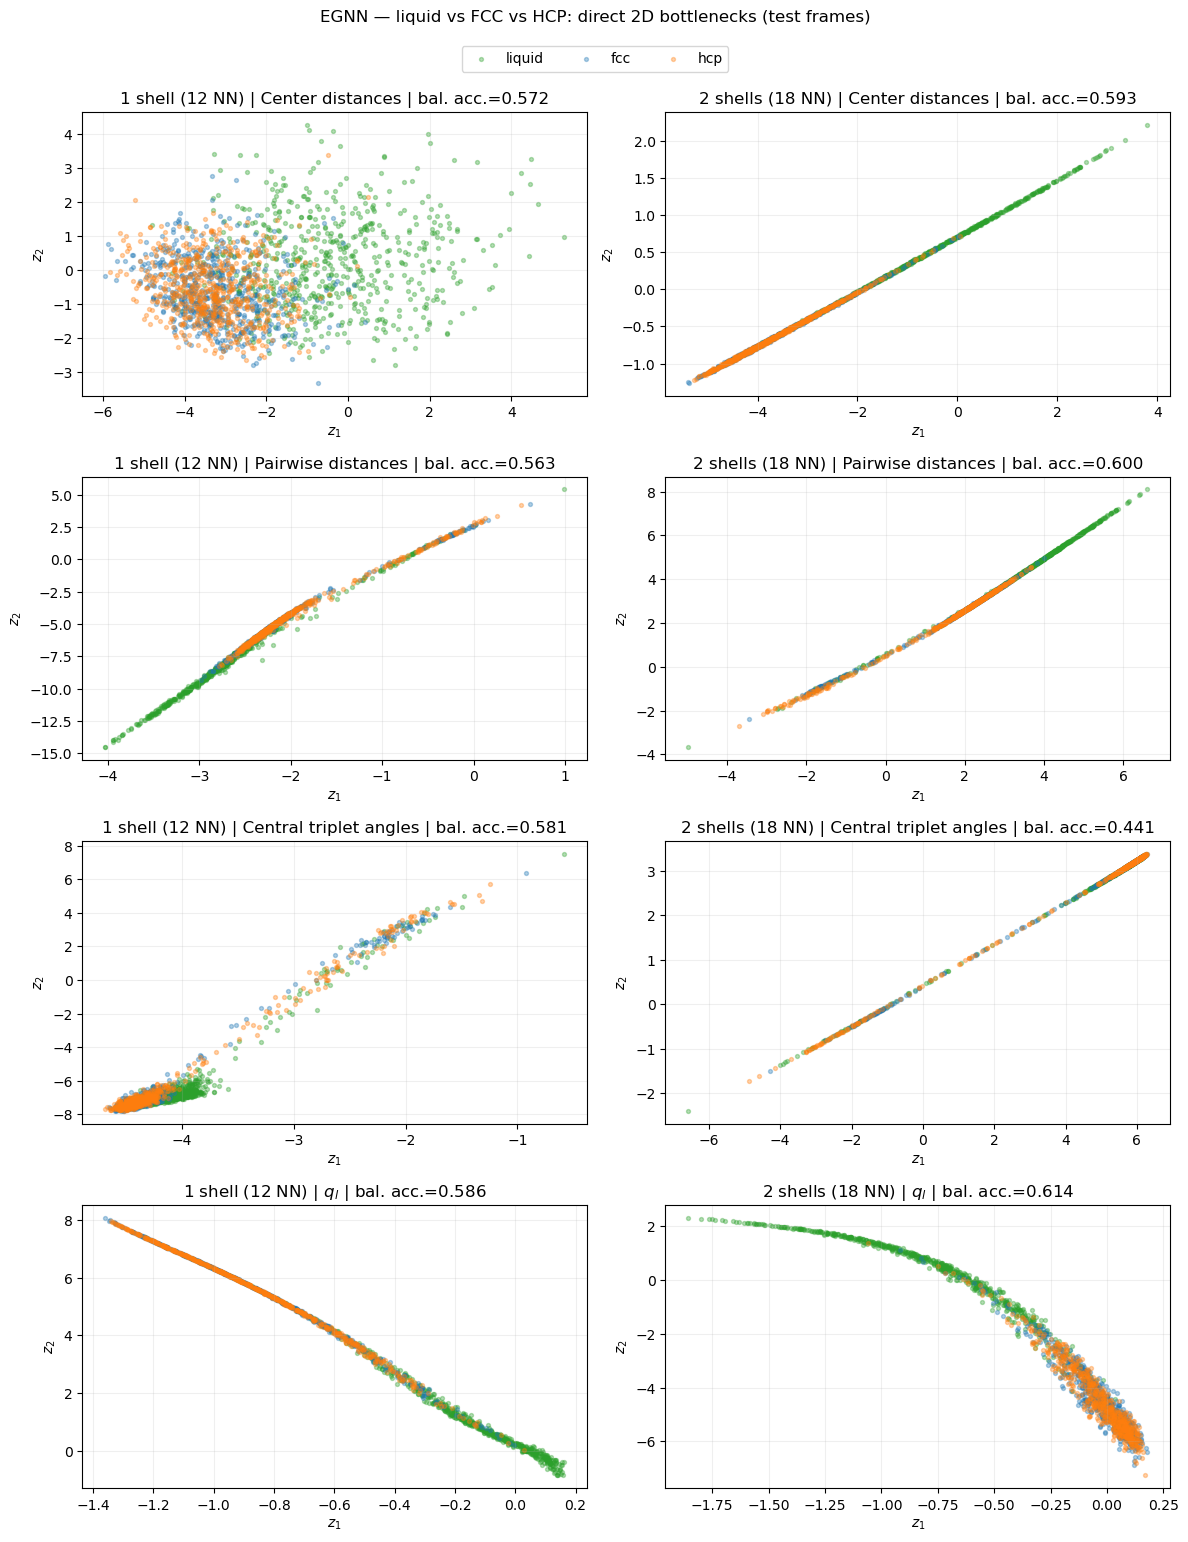

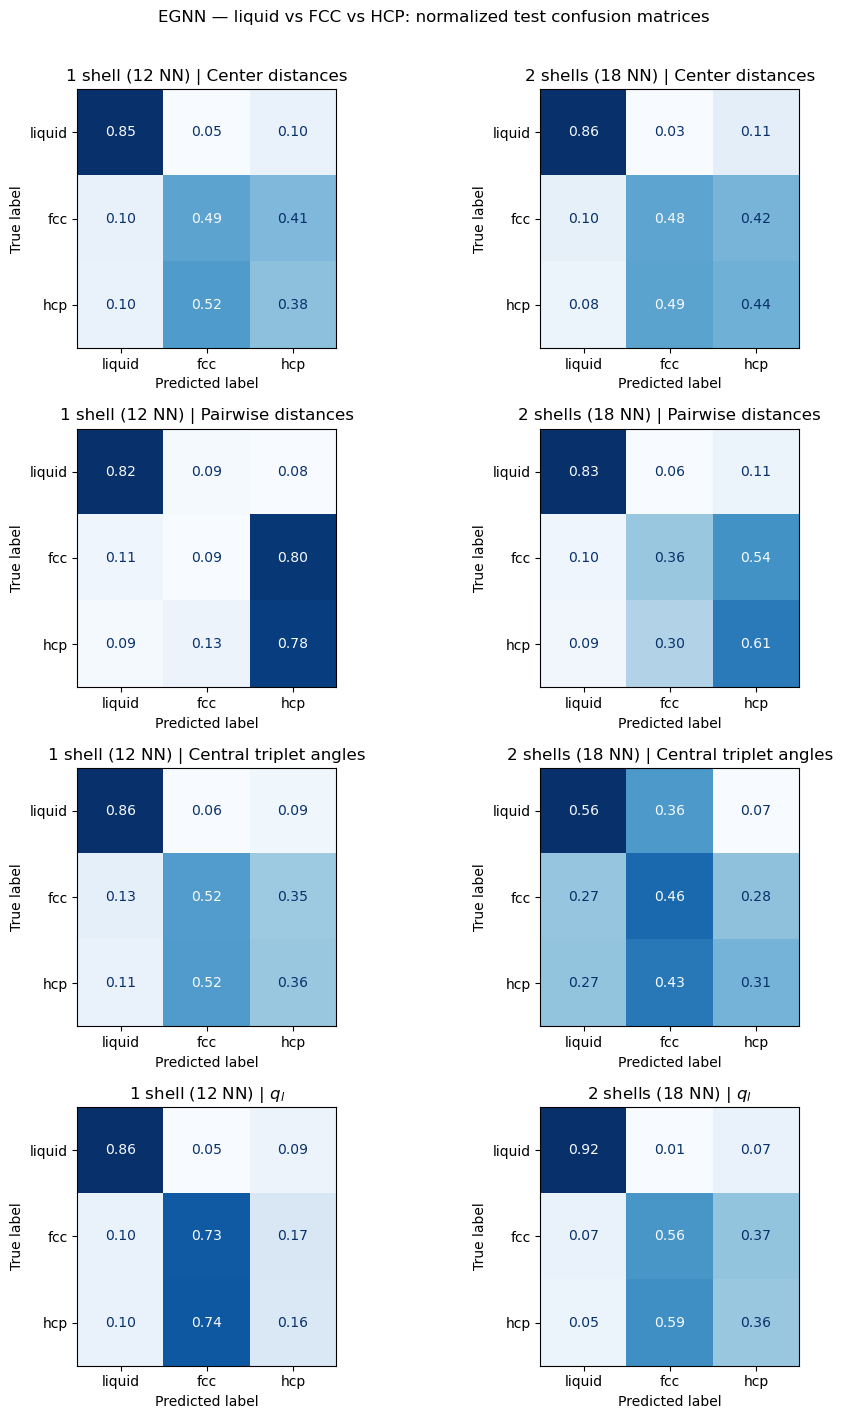

balanced_accuracy                         macro_f1  \
shell_label              1 shell (12 NN) 2 shells (18 NN) 1 shell (12 NN)   
target_label                                                                
$q_l$                             0.5856           0.6136          0.5469   
Center distances                  0.5721           0.5930          0.5671   
Central triplet angles            0.5808           0.4414          0.5720   
Pairwise distances                0.5626           0.5999          0.5103   

                                                roc_auc                   
shell_label            2 shells (18 NN) 1 shell (12 NN) 2 shells (18 NN)  
target_label                                                              
$q_l$                            0.6060          0.7998           0.8114  
Center distances                 0.5902          0.7952           0.8045  
Central triplet angles           0.4365          0.7880           0.6377  
Pairwise distances               0.5941          0.7872           0.7755

model                                    EGNN AE  simple AE
target_label           shell_label                         
$q_l$                  1 shell (12 NN)    0.5856     0.9073
                       2 shells (18 NN)   0.6136     0.9892
Center distances       1 shell (12 NN)    0.5721     0.5926
                       2 shells (18 NN)   0.5930     0.6243
Central triplet angles 1 shell (12 NN)    0.5808     0.7940
                       2 shells (18 NN)   0.4414     0.7352
Pairwise distances     1 shell (12 NN)    0.5626     0.6532
                       2 shells (18 NN)   0.5999     0.9104

In [32]:
if RUN_EGNN:
    plot_multiclass_latent_grid(
        egnn_artifacts,
        EGNN_TARGET_ORDER,
        EGNN_TARGET_LABELS,
        "EGNN — liquid vs FCC vs HCP",
    )
    plot_multiclass_confusion_grid(
        egnn_artifacts,
        EGNN_TARGET_ORDER,
        EGNN_TARGET_LABELS,
        "EGNN — liquid vs FCC vs HCP",
    )

    egnn_probe_table = egnn_scores.pivot(
        index="target_label",
        columns="shell_label",
        values=["balanced_accuracy", "macro_f1", "roc_auc"],
    )
    display(egnn_probe_table.round(4))

    matched_comparison = pd.concat(
        [
            three_main_scores[
                ["shell_label", "feature_label", "balanced_accuracy"]
            ].rename(columns={"feature_label": "target_label"}).assign(model="simple AE"),
            egnn_scores[
                ["shell_label", "target_label", "balanced_accuracy"]
            ].assign(model="EGNN AE"),
        ],
        ignore_index=True,
    )
    display(
        matched_comparison.pivot_table(
            index=["target_label", "shell_label"],
            columns="model",
            values="balanced_accuracy",
        ).round(4)
    )

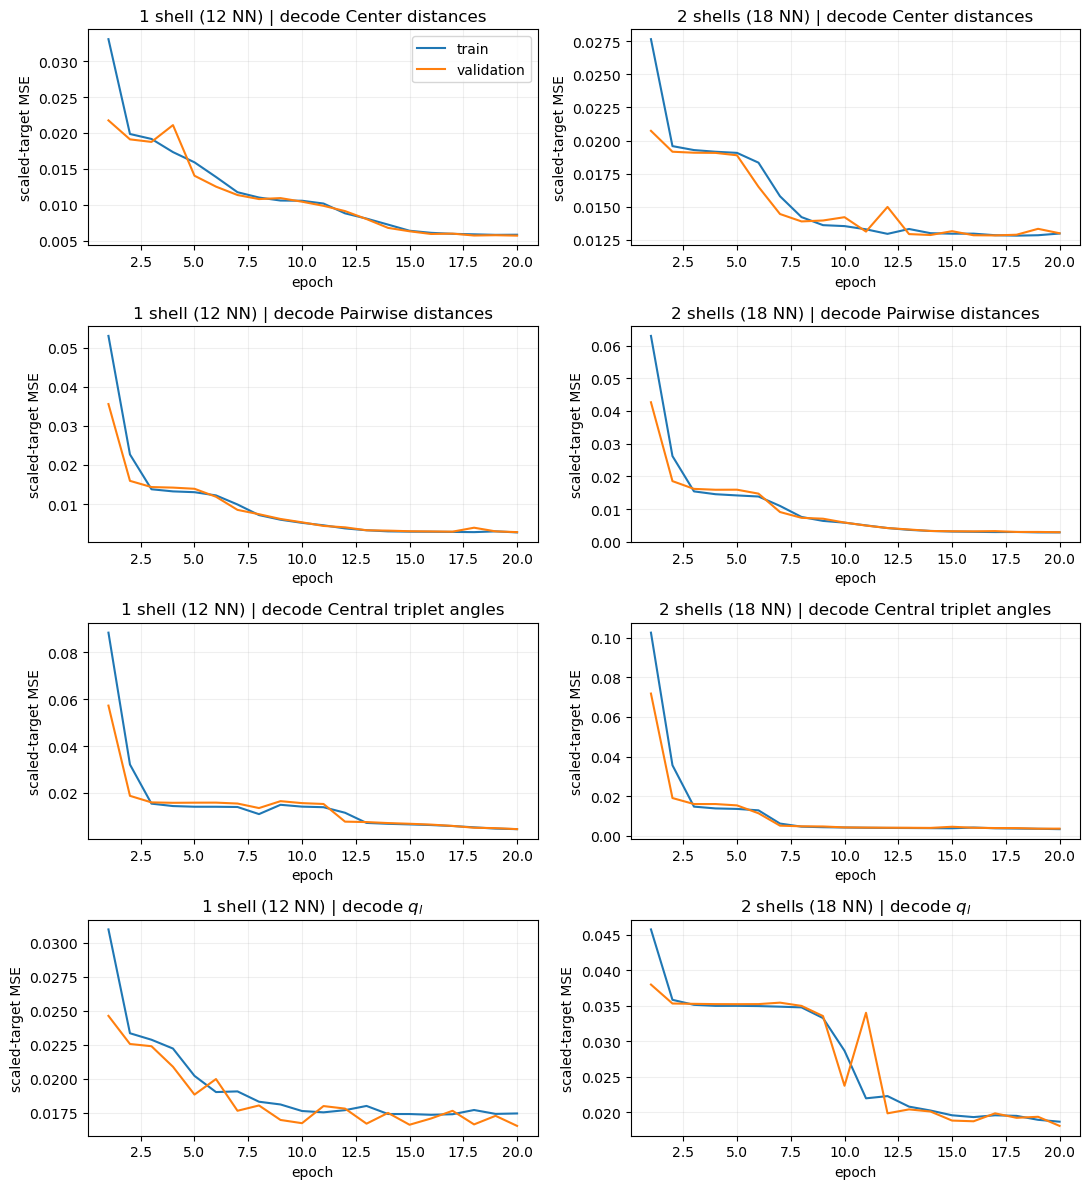

In [33]:
if RUN_EGNN:
    fig, axes = plt.subplots(
        len(EGNN_TARGET_ORDER),
        len(SHELL_ORDER),
        figsize=(11, 12),
        squeeze=False,
    )
    for row, target_kind in enumerate(EGNN_TARGET_ORDER):
        for col, shell_name in enumerate(SHELL_ORDER):
            ax = axes[row, col]
            history = egnn_artifacts[(shell_name, target_kind)]["history"]
            epochs = np.arange(1, len(history["train_mse"]) + 1)
            ax.plot(epochs, history["train_mse"], label="train")
            ax.plot(epochs, history["val_mse"], label="validation")
            ax.set_title(
                f"{SHELL_CONFIG[shell_name]['label']} | "
                f"decode {EGNN_TARGET_LABELS[target_kind]}"
            )
            ax.set_xlabel("epoch")
            ax.set_ylabel("scaled-target MSE")
            ax.grid(alpha=0.2)
    axes[0, 0].legend()
    plt.tight_layout()
    plt.show()

### Optional EGNN robustness hook

Setting `RUN_EGNN_ROBUSTNESS=True` repeats the complete EGNN suite over the same 30 seeds. This means 240 graph-autoencoder fits (30 seeds × 2 shells × 4 targets), so it is off by default. The output schema matches the simple-AE robustness tables and uses the same three-class chance level.

In [34]:
if RUN_EGNN and RUN_EGNN_ROBUSTNESS:
    egnn_score_frames = [egnn_scores]
    for seed in ROBUSTNESS_SEEDS:
        if seed == VISUAL_SEED:
            continue
        print(f"EGNN robustness run for seed {seed}")
        seeded_scores, _, _ = run_egnn_suite(
            seed,
            keep_artifacts=False,
            verbose=False,
        )
        egnn_score_frames.append(seeded_scores)

    egnn_robustness_scores = pd.concat(egnn_score_frames, ignore_index=True)
    display(
        egnn_robustness_scores
        .groupby(["target_label", "shell_label"])[list(metric_names)]
        .agg(["mean", "std", "min", "max"])
        .round(4)
    )
    plot_seed_boxplots(
        egnn_robustness_scores.rename(
            columns={"target": "feature", "target_label": "feature_label"}
        ),
        EGNN_TARGET_ORDER,
        EGNN_TARGET_LABELS,
        "EGNN — liquid vs FCC vs HCP",
        chance_level=1 / 3,
    )

### EGNN interpretation notes

- The graph encoder has access to the same local coordinates for every decoder target; only the unsupervised reconstruction pressure changes.
- A two-dimensional latent is intentionally severe. If reconstruction and probing both fail, a later latent-width ablation can distinguish an information bottleneck from an architectural problem.
- Radius and pairwise targets emphasize radial geometry; triplets and $q_l$ place progressively stronger pressure on angular order.
- The decoder never reconstructs raw coordinates, avoiding the need to align orientations or construct an equivariant coordinate decoder.
- The current second-shell $q_l$ target is Lechner–Dellago averaged but was generated with 12 descriptor neighbors. Regenerate the exact 18-neighbor files before treating that row as a strict second-shell $q_l$ result.